In [1]:
import pandas
import copy
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sbn
import sys
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp


# show all elements of a dataframe
# pandas.set_option("display.max_rows", None)
pandas.set_option("display.max_columns", None)


sys.path.append("../src/")

In [ ]:
races = pd.read_csv('../dataset/preprocessedRaces.csv', sep=",")
races.head()

In [ ]:
races.isna().sum()

In [ ]:
races.dtypes

In [ ]:
cyclists = pd.read_csv('../dataset/preprocessedCyclists.csv', sep=",")
cyclists.head()

In [ ]:
cyclists.isna().sum()

In [ ]:
cyclists.dtypes

In [ ]:
placements = pd.read_csv('../dataset/preprocessedPlacements.csv', sep=",")
placements.head()

In [ ]:
placements.isna().sum()

In [ ]:
placements.dtypes

# Clustering for cyclists

## Outliers Detection

In [11]:
def show_hist_and_box_plot(dataframe, column_name):
    column = dataframe[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram 
    sbn.histplot(column, bins='sturges', ax=axes[0])
    axes[0].set_title(f'Histogram of {column.name}', fontweight='bold')
    axes[0].set_xlabel(column.name) 
    axes[0].set_ylabel('Frequency')
    
    # Boxplot
    boxplot_dict = axes[1].boxplot(column[~np.isnan(column)])  # Removes the NaNs to avoid problems
    axes[1].set_title(f'Boxplot of {column.name}', fontweight='bold')
    axes[1].set_xlabel(column.name)
    
    # Extraction of the outliers from the boxplot and printing of them
    outliers = [flier.get_ydata() for flier in boxplot_dict['fliers']]
    outliers_values = list({value for sublist in outliers for value in sublist})

    plt.tight_layout()  # Avoid overlapping
    plt.show()

    print(f"Outliers in {column.name}: {outliers_values}")

In [12]:
def calculate_outlier_bounds(dataframe, column_name):
    Q1 = dataframe[column_name].quantile(0.25)
    Q3 = dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1
    min_ = dataframe[column_name].min()
    max_ = dataframe[column_name].max()
    lower_bound = max(min_, Q1 - 1.5 * IQR)
    upper_bound = min(max_, Q3 + 1.5 * IQR)
    return {"lower": lower_bound, "upper": upper_bound}

Feature selection based on NAN values and high correlation

In [ ]:
numeric_columns = ['BMI', 'median position', 'std_dev position', '# cyclist races', 'birth_year']
numeric_cyclists_df = cyclists[numeric_columns]
numeric_cyclists_df

In [ ]:
pearson_matrix = numeric_cyclists_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

We will now display the distributions of the selected columns and address the most extreme outliers based on these initial distributions, essentially taking a snapshot of the initial state of the dataframe _cyclists_. We will not adopt a cumulative approach, where the removal of outliers from one column would affect the subsequent distributions of the other columns

In [ ]:
for column in numeric_columns:
    show_hist_and_box_plot(cyclists,column)
    bounds = calculate_outlier_bounds(cyclists, column)
    lower_bound = round(bounds['lower'], 2)
    upper_bound = round(bounds['upper'], 2)
    
    outliers_list = []
    outliers = cyclists[
        (cyclists[column] < lower_bound) | (cyclists[column] > upper_bound)
    ]

    column_outliers_count = len(outliers)

    column_outliers_df = pd.DataFrame({
        "Name": outliers['name'],
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Value": outliers[column].round(2)
    })
    if(column_outliers_count > 0):
        display(column_outliers_df)
    print(f"Number of outliers in {column}: {column_outliers_count}")

In [16]:
def check_all_outliers(df):

    # dataframe to keep track of outliers for each row
    outlier_flags = pd.DataFrame(index=df.index)

    for column in numeric_columns:
        bounds = calculate_outlier_bounds(df, column)
        lower_bound = bounds['lower']
        upper_bound = bounds['upper']
        
        # set rows with outliers for the current column
        outlier_flags[column] = (df[column] < lower_bound) | (df[column] > upper_bound)

    # count the number of column with outliers for each row
    outlier_flags['outlier_count'] = outlier_flags.sum(axis=1)

    # compute the percentage of columns with outliers for each row
    outlier_flags['outlier_percentage'] = (outlier_flags['outlier_count'] / len(numeric_columns)) * 100

    # rows with at least one outlier
    rows_with_outliers = outlier_flags[outlier_flags['outlier_count'] > 0]

    display(rows_with_outliers)

    print(f"Total number of rows: {len(df)}")
    print(f"Total rows with outliers: {len(rows_with_outliers)}")
    print(f"Percentage of rows with outliers: {(len(rows_with_outliers) / len(df)) * 100:.2f}%")

    return rows_with_outliers

In [ ]:
rows_with_outliers = check_all_outliers(numeric_cyclists_df)

In [ ]:
rows_with_outliers[rows_with_outliers['outlier_count'] > 1]


### Outliers elimination
For outlier elimination, we follow an approach that focuses on identifying the most extreme values by using intervals beyond the lower and upper bounds. This allows us to remove only the truly extreme outliers without significantly altering the distribution or the representativeness of the data. This way, we preserve the integrity of the dataset while addressing the issue of outliers effectively.


In [19]:
def compare_box_plots(dataframe1, dataframe2, column_name):
    column1 = dataframe1[column_name]
    column2 = dataframe2[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Boxplot1
    boxplot_dict = axes[0].boxplot(column1[~np.isnan(column1)])  # Removes the NaNs to avoid problems
    axes[0].set_title(f'Boxplot before outliers cleaning', fontweight='bold')
    axes[0].set_xlabel(column1.name)

    # Boxplot2
    boxplot_dict = axes[1].boxplot(column2[~np.isnan(column2)])  # Removes the NaNs to avoid problems
    axes[1].set_title(f'Boxplot after outliers cleaning', fontweight='bold')
    axes[1].set_xlabel(column2.name)


    plt.tight_layout() 
    plt.show()


In [20]:
def compare_distributions(dataframe1, dataframe2, column_name):
    column1 = dataframe1[column_name]
    column2 = dataframe2[column_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
   
    # Histogram1 
    sbn.histplot(column1, bins='sturges', ax=axes[0])
    axes[0].set_title(f'Histogram before outliers cleaning', fontweight='bold')
    axes[0].set_xlabel(column1.name) 
    axes[0].set_ylabel('Frequency')

    #Histogram2
    sbn.histplot(column2, bins='sturges', ax=axes[1])
    axes[1].set_title(f'Histogram after outliers cleaning', fontweight='bold')
    axes[1].set_xlabel(column2.name) 
    axes[1].set_ylabel('Frequency')


    plt.tight_layout() 
    plt.show()


In [21]:
def compare_distributions_consistent(dataframe1, dataframe2, column_name):
    column1 = dataframe1[column_name]
    column2 = dataframe2[column_name]
    
    # Combine the two datasets and calculate shared bin edges
    combined_data = np.concatenate([column1, column2])
    bins = np.histogram_bin_edges(combined_data, bins='sturges')  # Using the same binning method for consistency
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram 1
    sbn.histplot(column1, bins=bins, ax=axes[0])
    axes[0].set_title('Histogram before outliers cleaning', fontweight='bold')
    axes[0].set_xlabel(column1.name)
    axes[0].set_ylabel('Frequency')

    # Histogram 2
    sbn.histplot(column2, bins=bins, ax=axes[1])
    axes[1].set_title('Histogram after outliers cleaning', fontweight='bold')
    axes[1].set_xlabel(column2.name)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [22]:
def analyze_outliers(dataframe, column, lower_bound, upper_bound, num_ranges_up, num_ranges_down, range_increment_up, range_increment_down):
    # Identifica gli outliers
    outliers = dataframe[
        (dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)
    ]
    
    outliers_values = outliers[column].round(2)

    outliers_above = outliers[outliers[column] > upper_bound]
    outliers_below = outliers[outliers[column] < lower_bound]

    print(f"Outliers above upper bound ({upper_bound}): {len(outliers_above)}")
    print(f"Outliers below lower bound ({lower_bound}): {len(outliers_below)}")

    total_outliers = len(outliers_values)
    print(f"Total outliers: {total_outliers}")

    # Intervalli sopra l'upper bound (se ci sono outliers sopra)
    if not outliers_above.empty:
        upper_ranges = [upper_bound + i * range_increment_up for i in range(num_ranges_up + 1)]

        upper_ranges_outliers_counts = []
        for i in range(len(upper_ranges) - 1):
            range_min = upper_ranges[i]
            range_max = upper_ranges[i + 1]
            count = len(outliers_values[
                (outliers_values >= range_min) &
                (outliers_values < range_max)
            ])
            upper_ranges_outliers_counts.append((range_min, range_max, count))
            print(f"Number of outliers in the range of [{range_min}, {range_max}]: {count}")
        
        outliers_above_last_range = len(outliers_values[outliers_values >= upper_ranges[-1]])
        print(f"Number of outliers > {upper_ranges[-1]}: {outliers_above_last_range}\n")
    else:
        print("No outliers above the upper bound.")
        upper_ranges_outliers_counts = []
        outliers_above_last_range = 0

    # Intervalli sotto il lower bound (se ci sono outliers sotto)
    if not outliers_below.empty:
        lower_ranges = [lower_bound - i * range_increment_down for i in range(num_ranges_down + 1)]

        lower_ranges_outliers_counts = []
        for i in range(len(lower_ranges) - 1):
            range_min = lower_ranges[i + 1]  # Range più piccolo
            range_max = lower_ranges[i]      # Range più grande
            count = len(outliers_values[
                (outliers_values < range_max) &
                (outliers_values >= range_min)
            ])
            lower_ranges_outliers_counts.append((range_min, range_max, count))
            print(f"Number of outliers in the range of [{range_min}, {range_max}]: {count}")
        
        outliers_below_last_range = len(outliers_values[outliers_values < lower_ranges[-1]])
        print(f"Number of outliers < {lower_ranges[-1]}: {outliers_below_last_range}")
    else:
        print("No outliers below the lower bound.")
        lower_ranges_outliers_counts = []
        outliers_below_last_range = 0

    # return {
    #     "total_outliers": total_outliers,
    #     "upper_ranges_counts": upper_ranges_outliers_counts,
    #     "outliers_above_last_range": outliers_above_last_range,
    #     "lower_ranges_counts": lower_ranges_outliers_counts,
    #     "outliers_below_last_range": outliers_below_last_range
    # }

#### _# cyclist races_ (530)
We evaluate different ranges of values (in increments of 200) above the upper bound, selecting a reasonable threshold beyond which outliers are considered extreme

In [23]:
bound = calculate_outlier_bounds(cyclists, "# cyclist races")
lower_bound_n_cyclist_races = bound['lower']
upper_bound_n_cyclist_races = bound['upper']

In [ ]:
analyze_outliers(cyclists, "# cyclist races", lower_bound_n_cyclist_races, upper_bound_n_cyclist_races, 7, 7, 100, 100)

We choose a value between [525, 725], which provides a good compromise for removing a significant number of outliers without overly altering the initial distribution. A value of 600 appears to be the most appropriate.

In [ ]:
len(cyclists[cyclists['# cyclist races'] > 600])

For better statistical precision, we rely on a quartile value that is close to 600. It is about the 98nd percentile.

In [ ]:
upper_extreme_quantile = cyclists["# cyclist races"].quantile(0.98)
upper_extreme_quantile

In [ ]:
cleaned_cyclists_df = cyclists.copy()  

cleaned_cyclists_df = cleaned_cyclists_df[
    (cleaned_cyclists_df['# cyclist races'] <=  upper_extreme_quantile)
]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len(cyclists) - len(cleaned_cyclists_df)}")

As shown in the below distribution and box plot graphs for the _# cyclist races_ column, the cleaned data does not deviate significantly from the original values. The core structure and range of this column remain consistent, while the most extreme outliers (> 600) have been effectively removed. This ensures that the cleaning process focused specifically on this column without distorting its overall characteristics.

In [ ]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "# cyclist races")

In [ ]:
compare_box_plots(cyclists, cleaned_cyclists_df, "# cyclist races")

In [ ]:
cleaned_cyclists_df
print(len(cyclists))
print(len(cleaned_cyclists_df))



#### BMI (66)


In [31]:
bound = calculate_outlier_bounds(cyclists, "BMI")
lower_bound_BMI = bound['lower']
upper_bound_BMI = bound['upper']


In [ ]:
lower_bound_BMI

In [ ]:
upper_bound_BMI

In [ ]:
analyze_outliers(cyclists, "BMI", lower_bound_BMI, upper_bound_BMI, 4, 4, 0.5, 0.5)

Let’s consider ‘extreme’ outliers as those below approximately 17.13 and above approximately 26.76. These thresholds correspond to the 0.092nd percentile  and the 99.98th percentile, respectively

In [ ]:
lower_extreme_quantile = cyclists["BMI"].quantile(0.00092)
upper_extreme_quantile = cyclists["BMI"].quantile(0.9998)
print(lower_extreme_quantile)
print(upper_extreme_quantile)

In [ ]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[
    (cleaned_cyclists_df['BMI'] <= upper_extreme_quantile) &
    (cleaned_cyclists_df['BMI'] >= lower_extreme_quantile)
]


print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")


As we can see, the distribution did not change much after removing the 8 most extreme outliers. Therefore, we expect this will not negatively impact the nature of the data.

In [ ]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "BMI")

In [ ]:
compare_box_plots(cyclists,cleaned_cyclists_df, "BMI")

#### std_dev position (17)

In [39]:
bound = calculate_outlier_bounds(cyclists, "std_dev position")
lower_bound_stdPos= bound['lower']
upper_bound_stdPos = bound['upper']


In [ ]:
analyze_outliers(cyclists, "std_dev position", lower_bound_stdPos, upper_bound_stdPos, 6, 6, 5, 5)

Let’s consider ‘extreme’ outliers as those above approximately 97.56, so the two most extreme ones. These thresholds correspond to the 99.97nd percentile.

In [ ]:
upper_extreme_quantile = cyclists["std_dev position"].quantile(0.9997)
upper_extreme_quantile

In [ ]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[(cleaned_cyclists_df['std_dev position'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")

In [ ]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "std_dev position")

In [ ]:
compare_box_plots(cyclists, cleaned_cyclists_df, "std_dev position",)

#### median position (8)

In [45]:
bound = calculate_outlier_bounds(cyclists, "median position")
lower_bound_medianPos = bound['lower']
upper_bound_medianPos = bound['upper']

In [ ]:
print(lower_bound_medianPos)
print(upper_bound_medianPos)

In [ ]:
analyze_outliers(cyclists, "median position", lower_bound_medianPos, upper_bound_medianPos, 6, 6, 5, 5)

Since there are no outliers that can be considered much more extreme than others, we try to eliminate all outliers and test the resulting distribution.

In [ ]:
len_before_cleaning = len(cleaned_cyclists_df)
cleaned_cyclists_df = cleaned_cyclists_df[
        (cleaned_cyclists_df["median position"] >= lower_bound_medianPos) & (cleaned_cyclists_df["median position"] <= upper_bound_medianPos)
    ]

print(f"Remaining rows after removal: {len(cleaned_cyclists_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_cyclists_df)}")

In [ ]:
compare_distributions_consistent(cyclists, cleaned_cyclists_df, "median position")

In [ ]:
compare_box_plots(cyclists, cleaned_cyclists_df, "median position")

As can be seen from the box plots and distributions above, removing all outliers has not significantly altered the nature of the data.

## Data normalization

In [51]:
from sklearn.preprocessing import StandardScaler

def standardize_fun(df):
    scaler = StandardScaler()
    scaler.fit(df)
    X = scaler.transform(df)
    standardized_df = pd.DataFrame(X, columns=df.columns, index=df.index)
    print(standardized_df)
    
    standardizer = {"scaler": scaler, "standardized_df": standardized_df}

    return standardizer
   


In [ ]:
cyclists = cleaned_cyclists_df
len(cyclists)

In [ ]:
numeric_cyclists_df = cyclists[numeric_columns]
numeric_cyclists_df

In [ ]:
standardizer = standardize_fun(numeric_cyclists_df)
standardized_cyclists_df = standardizer['standardized_df']

## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_cyclists_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced space

In [ ]:
# Try to apply PCA to get the optimal number of components
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_cyclists = pca_instance.fit_transform(standardized_cyclists_df)

print(f"# selected principal components: {pca_instance.n_components_}")

In [56]:
# pca = PCA()
# pca.fit(X) 

# # Compute the contribution (loadings) of each feature to each principal component
# loadings = pd.DataFrame(
#     pca.components_.T, # Transpose to align features with components
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Label columns as PC1, PC2, etc.
#     index=numeric_cyclists_df.columns # Use feature names as index
# )

# display(loadings)

# # Calculate the importance of each feature based on the first two principal components
# top_components = loadings.iloc[:, :2].abs().sum(axis=1) 
# top_variables = top_components.sort_values(ascending=False)


# print("\nFeatures sorted by contribution:")
# print(top_variables)


# selected_columns = top_variables.index.tolist()
# print(f"\nSelected columns: {selected_columns}")


In [ ]:
pca_std_numeric_cyclists

## Kmeans grid search

In [58]:
def kmeans_grid_search(df):
    results = []  # used to save sse and silhouette for each k
    previous_sse = None

    for k in range(2,16):
        kmeans = KMeans(n_clusters=k, max_iter=300, random_state=42)
        labels = kmeans.fit_predict(df)
        sse = kmeans.inertia_  # Calcola il SSE
        silhouette_avg = silhouette_score(df, labels) 

        if previous_sse is not None:
            sse_reduction_percentage = ((previous_sse - sse) / previous_sse) * 100
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}, sse reduction: {sse_reduction_percentage:.2f}%")
        else:
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}")
    
        # Salva i risultati
        results.append({"k": k, "sse": sse, "silhouette": silhouette_avg})
        previous_sse = sse
   
    return results

In [59]:
def k_means_evaluation_plotting(results):

    print(results)
    k_values = [result["k"] for result in results]
    sse_values = [result["sse"] for result in results]
    silhouette_values = [result["silhouette"] for result in results]

    plt.figure()
    plt.plot(k_values, sse_values, marker='o', label='SSE')
    plt.title('SSE with Elbow method')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('SSE')
    plt.show()

    plt.figure()
    plt.plot(k_values, silhouette_values, marker='o', label='Silhouette Score', color='orange')
    plt.title('Silhouette Score')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.show()

In [60]:
def get_best_k(results):
    best_result = max(results, key=lambda x: x["silhouette"])

    best_k = best_result["k"]
    return best_k

In [ ]:
results = kmeans_grid_search(pca_std_numeric_cyclists)

In [ ]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the optimal  k  values do not align. The Silhouette Score suggests  k = 2  as the optimal number of clusters, while the SSE indicates  k = 5  or  k = 6 . As a trade-off, we choose  k = 4 .

In [63]:
def kmeans_run(data, best_k, scaler):
    scaler = standardizer['scaler']
    print(f"\nBest k: {best_k}")

    # best kmeans with best clusters number
    best_kmeans = KMeans(n_clusters=best_k, random_state=42, init='k-means++', max_iter=300)

    best_kmeans.fit(data)
    print(f"k: {best_k}, Number of iterations: {best_kmeans.n_iter_}")

    centers = best_kmeans.cluster_centers_

    # Trasforma i centroidi dallo spazio PCA a quello standardizzato
    centers_standardized = pca_instance.inverse_transform(centers)

    # Inverso della trasformazione per ottenere i centroidi nello spazio originale (non normalizzato)
    centers_original_space = scaler.inverse_transform(centers_standardized)

    print("Centroids")
    print(centers_original_space)

    kmeans_data = {"best_kmeans": best_kmeans, "centroids": centers_original_space}

    return kmeans_data

  



In [ ]:
kmeans_data = kmeans_run(data=pca_std_numeric_cyclists, best_k=4, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']

In [ ]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

Let's print a summary of the average values for each feature within the clusters

In [ ]:
numeric_cyclists_df = numeric_cyclists_df.copy() 
# Add Cluster as a column to the dataset
numeric_cyclists_df['Cluster'] = best_kmeans.labels_

# Compute statistics for each feature grouped by cluster
detailed_cluster_stats = numeric_cyclists_df.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])

detailed_cluster_stats.columns = ['_'.join(col) for col in detailed_cluster_stats.columns]

display(detailed_cluster_stats)

## Distribution of points for each feature across clusters

In [67]:
def clusters_box_plot(df):

    columns = [col for col in df.columns if col != 'Cluster']
    n_rows = (len(columns) + 2 - 1) // 2  

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows), sharey=False)

    # Rendi axes un array 1D per un accesso più semplice
    axes = axes.flatten()

    for i, column in enumerate(columns):
        sbn.boxplot(x='Cluster', y=column, data=df, ax=axes[i])
        axes[i].set_title(f"Distribution of '{column}'")
        axes[i].set_xlabel("Cluster")
        axes[i].set_ylabel(column)

    # Nascondi subplot extra (se presenti)
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
clusters_box_plot(numeric_cyclists_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 4 clusters by considering points distribution for each feature:
- **Cluster 0** (984 points): 

  - **_BMI_**: values are centered around a median of 21, with a moderately tight interquartile range. There are some outliers on both the lower and upper ends, with the lowest BMI slightly above 18 and the highest below 26.
  
  - **_median position_**: this cluster has a wide enough IQR for the median position, but the narrowest among all other clusters, with values ranging from ~50 to ~90. The median is approximately 70. There are no outliers.

  - **_# cyclist races_**: cyclists in this cluster participated in the largest number of races with a median of 300. IQR is the widest and spreads from ~220 to ~380. There are no outliers.
  
  - **_birth\_year_**: this cluster has a median birth year around 1980, with an IQR ranging from ~1971 to ~ 1988. There are one or a few outliers below 1950.

  - **_std\_dev position_**: the median standard deviation of position is around 42 and IQR is the narrowest. This cluster has a lot of outliers on both the lower and the upper ends, below 20 and beyond 65.

- **Cluster 1** (1873 points): 

  - **_BMI_**: the median BMI is approximately 21, and outliers are present on both ends. The IQR depth is quite similar to that of Cluster 0, but with slighlty lower values.
  
  - **_median position_**: the median position is the highest compared to the other clusters. The median values is around 100 and there are many high-end outliers over 175, and many low-end outliers close to 5.

  - **_# cyclist races_**: the distribution shows a tighter IQR and a lower median, around 15. There are many high-end outliers, with values over 200.
  
  - **_birth\_year_**: the median birth year is ~1990, the highest compared to the other clusters. Outliers are present just above the ~1950s.

  - **_std\_dev position_**: the median std deviation of position is around 30 and the IQR ranges from ~20 to ~40. There are not outliers.

- **Cluster 2** (1664 points): 

  - **_BMI_**: the median BMI is around 22, the highest. There are many outliers up to over 26, and some around 19.
  
  - **_median position_**: this cluster has the widest IQR compared to the others, with a median position around ~90. There are some high-end and low-end outliers.

  - **_# cyclist races_**: the median of number of races in this cluster is about 50 and also contains a significant number of high-end outliers, the highest just below 400.
  
  - **_birth\_year_**: IQR here, ranges from ~1965 to ~1980 and the median value is approximately 1971. There are no outliers.

  - **_std\_dev position_**: this cluster has the highest median standard deviation of position, around 45. The are a lot of high-end outliers up to 100, and a lot of low-end outliers down to 0.

- **Cluster 3** (1434 points): 

  - **_BMI_**: median is about ~21 and the IQR is the slightly widest. There are few low-end outliers and many other high-end ones.
  
  - **_median position_**: the median position is the smallest here, about ~30, with some outliers on the upper end up to ~150.

  - **_# cyclist races_**: cyclists in this cluster have the smallest number of races, with a median around 15 and the tightest IQR. There are a lot of outliers on the upper part, up to about ~300
  
  - **_birth\_year_**: this cluster has the cyclists born in more distant years, with a median around 1955. Some outliers extend to earlier years, up to 1990s.

  - **_std\_dev position_**: this cluster has the smallest median standard deviation of position, ~15, but the widest IQR, ranging from ~0 to ~30, suggesting more consistency in performance. There are no outliers.




 

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cluster 0 could represent highly experienced cyclists with a median of ~300 races, the highest among all clusters. Their performance, however, is inconsistent, as indicated by a high median standard deviation of positions (~42) and many outliers. These cyclists, born around 1980.

#### Cluster 1
Cluster 1 consists of cyclists with a median birth year of ~1990 and limited race participation (~15 races). They reached the worst median positions (~100) but, despite this, their standard deviation of positions (~45) shows relatively consistent but average performance, characteristic of those still developing in the sport.

#### Cluster 2
Cluster 2 is characterized by cyclists born in the 70s, with moderate race experience (~50 races). Their performance varies significantly, as seen in the wide IQR for race positions and the highest median standard deviation (~45). This group seems to balance competitiveness with fluctuating results.

#### Cluster 3
Cluster 3 is composed of the cyclists born in more distant years, as reflected by their distant median birth year (~1955). Despite participating in fewer races overall, they achieve strong and consistent performance, with the best median race positions (~30) and the smallest variability in results. This group likely includes highly selective participants who compete less frequently but perform at a high level. 

But we must highlight that these results could only be distorted by the fact that they participated in very few competitions.

## Clusters visualization with feature distributions and centroids 

In [69]:
    
def clusters_pairplot(df, centroids):
    pairplot = sbn.pairplot(
        df,
        hue='Cluster',
        palette='Set1',
        diag_kind='kde',
        markers='o',
        plot_kws={'alpha': 0.5}
    )

    for i, ax in enumerate(pairplot.axes.flat):
        # Get features for each subplot
        row_feature = pairplot.axes.flat[i].get_ylabel()
        col_feature = pairplot.axes.flat[i].get_xlabel()

        # Add centroids only to relevant scatter plots, excluding diagonal ones
        if row_feature in df.columns and col_feature in df.columns:
            ax.scatter(
                centroids[:, df.columns.get_loc(col_feature)],  
                centroids[:, df.columns.get_loc(row_feature)], 
                marker='x', s=100, c='black', label='Centroid'
            )

    plt.legend()
    plt.show()

In [70]:
numeric_cyclists_df.to_csv("../../df_cyclists_cluster.csv", index=False)

In [ ]:
clusters_pairplot(numeric_cyclists_df, centroids)

### Pairplot analysis

By analyzing the paiplot above, we can try to analyze the 4 clusters and try to catch any relationships and patterns between the characteristics of the clusters that we were unable to catch with the box plots
- **Cluster 0**: 

  - **_std\_dev position_** vs **_# cyclist races**: cyclists with a high number of races tend to have higher standard deviations in their race positions, reflecting more variability in their performance. But this is also quite normal.
  
  - **_# cyclist races_** vs **_birth\_year_**: it seems that cyclists born in more recent years, tend to participate to more races.

- **Cluster 1**: 

  - **_birth\_year_** vs **_median position_**: it seems like that there is a light relationship. Cyclists with worse rankings (higher median positions) tend to be born in earlier years and viceversa.

  - **_median position_** vs **_BMI_**: there is a weak relationship: cyclists with better performance (low median position) have lower BMI values.

  - **_std\_dev position_** vs **_median position_**: cyclists with higher standard deviations in race positions tend to have better median position.
  
- **Cluster 2**: 

  -  **_BMI_** vs **_# cyclist races_**: it appears that cyclists with higher BMI have participated to more races.

  -  **_BMI_** vs **_std\_dev position_**: cyclists with higher BMI seems to have more consistent performances (lower std_dev position).
  
  -  **# cyclist races** vs **_std\_dev position_**: there is a slight relation: higher values of standard deviation of position correspond to lower number of cyclist races.
  
- **Cluster 3**: 
  
  - **_# cyclist races_** vs **_birth\_year_**: in this cluster, cyclists born in more recent years, tend do partecipate to more races, as in Cluster 0.
  
  - **_birth\_year_** vs **_median position_**: it seems that cyclist born after 1960s, have got worse median position (higher values)
  
  - **_std\_dev position_** vs **_# cyclist races**: as in Cluster 0, cyclists with a high number of races appear to have higher standard deviations in their race positions, reflecting more variability in their performance.
 



 

## Geographic distribution of cyclists across clusters
Here we analyzed the geographic distribution of cyclists across clusters by grouping them based on their geographic area and visualized the results. A bar chart was used to compare the counts of cyclists from different regions within each cluster. The chart highlights the relationships between geographic regions and cluster assignments, providing insights into how cyclists from various areas are distributed across the clusters.

In [ ]:
cross_df = pandas.crosstab(best_kmeans.labels_, cyclists['geo area'])

cross_df.plot(kind='bar', stacked=False, 
                   title='relationship per cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

# Clustering for races

## Outliers Detection

In [ ]:
numerical_cols = races.select_dtypes(include=['float64', 'int64', 'Int64']).columns
numerical_cols

In [ ]:
numeric_races_df = races[numerical_cols]
numeric_races_df

In [ ]:
numeric_races_df.isna().sum()

In [ ]:
numeric_races_df = numeric_races_df.dropna(axis=1, how='any')
numeric_races_df.isna().sum()

In [ ]:
numeric_races_df = numeric_races_df[['points', 'climb/length', 'median_delta', 'std_delta', 'startlist_quality', 'climb_total', 'length']]
numeric_races_df

Check pearson correlation between these non-nan numeric features

In [ ]:
pearson_matrix = numeric_races_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

Since _std\_delta_ and _median\_delta_ are highly correlated, we decide to drop _std\_delta_. Also _climb\_total_ and _length_ are moderately correlated.
Given that we already have the feature _climb/total_, we chose to drop _climb\_total_  while retaining _length_

In [ ]:
numeric_races_df = numeric_races_df.drop(['std_delta', 'climb_total'], axis=1)
numeric_races_df

In [ ]:
numeric_columns = numeric_races_df.columns
numeric_races_df['_url'] = races['_url']
numeric_races_df

In [ ]:
for column in numeric_columns:
    show_hist_and_box_plot(numeric_races_df,column)
    bounds = calculate_outlier_bounds(numeric_races_df, column)
    lower_bound = round(bounds['lower'], 3)
    upper_bound = round(bounds['upper'], 3)
    
    outliers_list = []
    outliers = numeric_races_df[
        (numeric_races_df[column] < lower_bound) | (numeric_races_df[column] > upper_bound)
    ]

    column_outliers_count = len(outliers)

    column_outliers_df = pd.DataFrame({
        "Url": outliers['_url'],
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Value": outliers[column].round(3)
    })
    if(column_outliers_count > 0):
        display(column_outliers_df)
    print(f"Number of outliers in {column}: {column_outliers_count}")

In [ ]:
rows_with_outliers = check_all_outliers(numeric_races_df)

In [ ]:
rows_with_outliers['outlier_count'].value_counts()

In [ ]:
rows_with_outliers[rows_with_outliers['outlier_count'] == 2]

In [ ]:
rows_with_outliers[rows_with_outliers['outlier_count'] == 3]

### Outliers elimination

#### points (510)

In [ ]:
numeric_races_df['points'].value_counts().sort_index()

In [87]:
bound = calculate_outlier_bounds(numeric_races_df, "points")
lower_bound_points = bound['lower']
upper_bound_points = bound['upper']

In [ ]:
print(lower_bound_points)
print(upper_bound_points)

In [ ]:
analyze_outliers(numeric_races_df, "points", lower_bound_points, upper_bound_points, 7, 7, 20, 20)

The most extreme outliers appear to be those with values > 315, which are all points = 350.

In [ ]:
numeric_races_df[numeric_races_df['points'] > 315]['points'].value_counts()

Points column represents fixed scores assigned to various types of cycling races. These scores are predetermined, and the values range from 18 to 350. According to the outliers detection, values above **175** are considered outliers. However, this results in identifying **510** rows as outliers, which is a substantial portion of the dataset. Removing all these rows would drastically alter the distribution. To address this issue, we analyzed different portions above 175 to identify the most extreme outliers.

Through this process, we observed that the most extreme outliers were those with the value 350, and all 53 of them are identical. These rows represent fixed scores that are meaningful in the context of the dataset. 
Since these high scores are predetermined and correspond to a specific category of races, it makes more sense to retain them in the dataset. This ensures that the clusters or future analyses are not biased by the absence of certain race types.

#### climb/length (145)

In [91]:
bound = calculate_outlier_bounds(numeric_races_df, "climb/length")
lower_bound_climb_length = bound['lower']
upper_bound_climb_length = bound['upper']

In [ ]:
print(lower_bound_climb_length)
print(upper_bound_climb_length)

In [ ]:
analyze_outliers(numeric_races_df, "climb/length", lower_bound_climb_length, upper_bound_climb_length, 8, 8, 0.01, 0.01)

Given the ranges above, it might be quite "safe" to try to consider outliers beyond 0.069 as extreme. It is about the 99.6th percentile.

In [ ]:
upper_extreme_quantile = numeric_races_df["climb/length"].quantile(0.996)
upper_extreme_quantile

In [ ]:
cleaned_races_df = numeric_races_df.copy()  

cleaned_races_df = cleaned_races_df[
    (cleaned_races_df['climb/length'] <=  upper_extreme_quantile)
]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len(numeric_races_df) - len(cleaned_races_df)}")

In [ ]:
compare_distributions_consistent(numeric_races_df, cleaned_races_df, "climb/length")

In [ ]:
compare_box_plots(numeric_races_df, cleaned_races_df, "climb/length")

As we can see, the distribution has not been significantly altered. The box plot now provides a better and more understandable visualization.

#### median_delta (402)

In [98]:
bound = calculate_outlier_bounds(numeric_races_df, "median_delta")
lower_bound_median_delta= bound['lower']
upper_bound_median_delta = bound['upper']

In [ ]:
print(lower_bound_median_delta)
print(upper_bound_median_delta)

In [ ]:
analyze_outliers(numeric_races_df, "median_delta", lower_bound_median_delta, upper_bound_median_delta, 6, 6, 1000, 1000)

In [ ]:
numeric_races_df['median_delta'].value_counts().sort_index()

The 3 most extreme values, above _7186.25_ are extremely higher compared to the others. 

In [ ]:
numeric_races_df[numeric_races_df['median_delta'] > 7186.25]['median_delta'].value_counts()

As we can see, the three values beyond 7186.25 can undoubtedly be considered the most extreme outliers. However, we could also include other extreme outliers, given that most values are concentrated within the first two intervals, up to 3186.25. Therefore, we can consider all values exceeding this threshold (3186.25) as extreme outliers.

This corresponds approximately to the 0.9992 quantile, meaning that only 0.08% of the data lies above this threshold. 

In [ ]:
upper_extreme_quantile = numeric_races_df["median_delta"].quantile(0.9992)
upper_extreme_quantile

In [ ]:
len_before_cleaning = len(cleaned_races_df)
cleaned_races_df = cleaned_races_df[(cleaned_races_df['median_delta'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_races_df)}")

In [ ]:
compare_distributions_consistent(numeric_races_df, cleaned_races_df, "median_delta")

In [ ]:
compare_box_plots(numeric_races_df, cleaned_races_df, "median_delta")

After removing the most extreme outliers, we can observe a significant change in the boxplot. Previously, the extreme values heavily skewed the visualization, making it difficult to interpret the majority of the data. Now, with the extreme outliers removed, the boxplot provides a clearer view of the distribution. Importantly, while the visualization has been adjusted, the distribution itself has not been significantly altered.

#### startlist_quality (260)

In [107]:
bound = calculate_outlier_bounds(numeric_races_df, "startlist_quality")
lower_bound_startlist= bound['lower']
upper_bound_startlist = bound['upper']

In [ ]:
print(lower_bound_startlist)
print(upper_bound_startlist)

In [ ]:
analyze_outliers(numeric_races_df, "startlist_quality", lower_bound_startlist, upper_bound_startlist, 15, 1, 20, 50)

Given that the outliers are fairly evenly distributed, there aren’t any outliers that stand out as more extreme than the others. Therefore, it could be reasonable to keep them all without removing any.

#### length (749)

In [110]:
bound = calculate_outlier_bounds(numeric_races_df, "length")
lower_bound_length= bound['lower']
upper_bound_length = bound['upper']

In [ ]:
print(lower_bound_length)
print(upper_bound_length)

Since we need to account for multiple intervals, we execute analyze_outliers twice: once for the most extreme low-end outliers and once for the most extreme high-end outliers.

In [ ]:
# high-end outliers
analyze_outliers(numeric_races_df, "length", lower_bound_length, upper_bound_length, 20, 0, 1000, 0)

It is not easy to establish which ones are considered more extreme, but let's try to consider those few that go beyond _299250_

In [ ]:
# low-end outliers
analyze_outliers(numeric_races_df, "length", lower_bound_length, upper_bound_length, 0, 26, 0, 4000)

Given that the low-end outliers below the lower bound are fairly evenly distributed, none of them stand out as significantly more extreme than the others. Therefore, it could be reasonable to retain them all.

So, we will focus on removing only the few considered extreme above the upper bound. Before we supposed to consider those above 299250 as extreme outliers, it corresponds approximately the 0.9992 quantile.

In [ ]:
upper_extreme_quantile = numeric_races_df["length"].quantile(0.9992)
upper_extreme_quantile

In [ ]:
len_before_cleaning = len(cleaned_races_df)
cleaned_races_df = cleaned_races_df[(cleaned_races_df['length'] <= upper_extreme_quantile)]

print(f"Remaining rows after removal: {len(cleaned_races_df)}")
print(f"Removed rows: {len_before_cleaning - len(cleaned_races_df)}")

In [ ]:
compare_distributions_consistent(numeric_races_df, cleaned_races_df, "length")

In [ ]:
compare_box_plots(numeric_races_df, cleaned_races_df, "length")

As expected, removing only 4 outliers does not impact the distribution or the box plot in any meaningful way.

In [ ]:
cleaned_races_df.shape

## Data Normalization

In [ ]:
numeric_races_df = cleaned_races_df
numeric_races_df = numeric_races_df.drop('_url', axis=1)
standardizer = standardize_fun(numeric_races_df)
standardized_races_df = standardizer['standardized_df']

## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_races_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced spac

In [ ]:
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_races = pca_instance.fit_transform(standardized_races_df)

print(f"# selected principal components: {pca_instance.n_components_}")

In [121]:
# pca = PCA()
# pca.fit(standardized_races_df) 

# # Compute the contribution (loadings) of each feature to each principal component
# loadings = pd.DataFrame(
#     pca.components_.T, # Transpose to align features with components
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Label columns as PC1, PC2, etc.
#     index=numeric_races_df.columns # Use feature names as index
# )

# display(loadings)

# # Calculate the importance of each feature based on the first two principal components
# top_components = loadings.iloc[:, :2].abs().sum(axis=1) 
# top_variables = top_components.sort_values(ascending=False)


# print("\nFeatures sorted by contribution:")
# print(top_variables)


# selected_columns = top_variables.index.tolist()
# print(f"\nSelected columns: {selected_columns}")


## Kmeans grid search

In [ ]:
results = kmeans_grid_search(pca_std_numeric_races)

In [ ]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the values approximately align at k = 5, where the Silhouette Score is the highest.

In [ ]:
kmeans_data = kmeans_run(data=pca_std_numeric_races, best_k=5, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']

In [ ]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

In [ ]:
numeric_races_df = numeric_races_df.copy() 
# Add Cluster as a column to the dataset
numeric_races_df['Cluster'] = best_kmeans.labels_

# Compute statistics for each feature grouped by cluster
detailed_cluster_stats = numeric_races_df.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])

detailed_cluster_stats.columns = ['_'.join(col) for col in detailed_cluster_stats.columns]


display(detailed_cluster_stats)


## Distribution of points for each feature across clusters

In [ ]:
clusters_box_plot(numeric_races_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 5 clusters by considering points distribution for each feature:
- **Cluster 0** (688 points): 
  
  - **_points_**: median value is 100, and IQR is extremely narrow, the narrowest. There are low-end outliers, with the minimum around 50.
  
  - **_climb/lenght_**: the IQR is slightly narrow, with a median around ~0.01, the lowest compared to the other clusters. Several outliers are found in the upper part, up to approximately ~0.025.

  - **_median\_delta_**: IQR is moderate, ranging from just above 0 up to around ~400. There are many high-end outliers, the highest around ~1500. The median is approximately ~50.

  - **_startlist\_quality_**: the median of startlist_quality is the highest, meaning this is the cluster with races that attract the most competitive cyclists. IQR ranges from ~1500 to ~1800. There are no outliers.

  - **_length_**: the IQR is the widest, ranging from ~160000 to ~210000. The median races length is around ~190000. There are many low-end and some high-end outliers, with the minimum ~4000 and the maximum around ~299000.

- **Cluster 1** (2446 points): 
  
  - **_points_**: median here is 50 and IQR ranges from ~50 to ~80. There are one or few high-end outliers, just above 150.
  
  - **_climb/lenght_**: median is slightly higher compared to the Cluster 0, with a median around ~0.011 and a just wider IQR. We can find several outliers in the upper part, up to 0.03.  

  - **_median\_delta_**: IQR is among the narrowest, and the median is the lowest, just above 0. There are many high-end outliers. 
  
  - **_startlist\_quality_**: median is around ~850 and IQR ranges from ~700 to ~1000. There are several low-end outliers, with the minimum aroung ~100. This is the only cluster with low-end outliers here.

  - **_length_**: IQR is among the narrowest, and the median races length is just below the one in CLuster 0, around ~180000. There are both low and high end outliers.
  
- **Cluster 2** (861 points):

  - **_points_**: IQR is among the widest, ranging from ~50 to ~100. The median value of points is around ~80. There are no outliers.
  
  - **_climb/lenght_**: this ratio here is the highest, probably indicating races with the greater number of climbs per length. Median is around ~0.022. There are a lot of outliers, especially in the upper part, reaching up above 0.06.

  - **_median\_delta_**: the median delta is the highest compared to the other clusters. Also the IQR is the widest, ranging from just below 1000 up to ~1500. The median value is around ~1200. There are several high-end outliers up to ~3000.
  
  - **_startlist\_quality_**: IQR is the widest, ranging from ~850 to ~1350. The median is just above 1000. There are no outliers.

  - **_length_**: the median here is quite similar to the ones in the previous clusters, but slightly lower. The IQR ranges from around ~155000 to ~200000. There are many low-end outliers and few in the upper part.
  
- **Cluster 3** (508 points):
  
  - **_points_**: here there are races that give the most points, with a median around ~275. IQR ranges from ~225 to ~275. There are no outliers.
  
  - **_climb/lenght_**: this ratio here is the second highest, with a median around ~0.013. There are no outliers.

  - **_median\_delta_**: median is approximately ~250 and there are several high-end outliers, with the highest around ~1700.
  
  - **_startlist\_quality_**: IQR is enough wide, ranging from ~750 to ~1200, and a median of ~850. There are no outliers. 

  - **_length_**: this cluster contains the longest races, with a median around ~250000. There are some low-end outliers.
  
- **Cluster 4** (747 points):
  
  - **_points_**: the number of points here is the lowest, with a median just above 50. IQR is quite similar to that of Cluster 1. There are no outliers.
  
  - **_climb/lenght_**: the IQR is the widest, and the median is around ~0.012. There are no outliers.

  - **_median\_delta_**: the IQR is among the narrowest with a median around ~50. There are several high-end outliers, up to ~800.
  
  - **_startlist\_quality_**: the median is similar to that of Cluster 1, around ~850, but the IQR is slightly wider. This is the only cluster containing high-end outliers for this feature, with the maximum up to 2000.

  - **_length_**: here there are the shorter races, with a median length around ~23000. There are several high-end outliers, up to ~150000.
  

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cluster 0 may is characterized by races among that give the most _points__, with a median of 100. The IQR is very narrow, showing little variability in the points distribution, although there are low-end outliers with points dropping to around 50. These races have the lowest _climb/length_ ratio, with a median of 0.01, indicating easier climbs. A few outliers extend up to 0.025, suggesting some races with greater climbing challenges.

Performance variability, as indicated by _median\_delta_, is moderate. High-end outliers, however, reach up to approximately 1500, reflecting a subset of cyclists with extreme inconsistency in their performance. This cluster has the highest startlist_quality and no outliers, suggesting consistently competitive races. The races in this cluster are generally long, with a median length of 190,000 meters, though the range is broad. Outliers at both extremes indicate a mix of shorter and longer races.

#### Cluster 1
Cluster 1 is characterized by races among that give fewer _points__, with a median of 50 and an IQR ranging from 50 to 80. The _climb/length_ ratio has a median of 0.011, slightly higher than in Cluster 0, with a moderately narrow IQR. Outliers in the upper range reach up to 0.03, indicating a small number of more challenging races.

Performance consistency, as measured by _median\_delta_, is relatively stable for most races, with a narrow IQR. However, a significant number of high-end outliers suggest different races with extreme inconsistency. The _startlist\_quality_ in this cluster is moderate, with a median of approximately 850. Notably, this cluster includes low-end outliers with startlist quality dropping to around 100, reflecting a mix of competitive and less competitive events. Race lengths are typically around 180,000 meters, with a narrow IQR.

#### Cluster 2
Cluster 2 includes moderate races in terms of _points_ awarded, with a median of 80 and a relatively wide IQR from 50 to 100. The _climb/length_ ratio is the highest among all clusters, with a median of 0.022, reflecting the challenging nature of these races. Upper outliers extend beyond 0.06, indicating some extreme climbing conditions.

The _median\_delta_ feature shows the highest performance variability. There are also several high-end outliers, highlighting races with extreme inconsistency. _Startlist\_quality_ in this cluster is moderately high, with a median of just above 1000 and the widest IQR. Race lengths are moderate, with a median of 178,000 meters and an IQR from 155,000 to 200,000 meters. Low-end outliers reflect shorter races, while a few high-end outliers suggest longer ones.

#### Cluster 3
Cluster 3 represents the races that give the most _points_, which a median of 275. _The climb/length_ ratio is moderate, with a median of 0.013 and no outliers, indicating a consistent difficulty level, considering the climbs.

_Median\_delta_ values are relatively stable. High-end outliers reach up to 1700, showing occasional variability in cyclist performance. These races are the longest in terms of distance, with a median length of 250,000 meters and a narrow IQR. A few low-end outliers indicate the presence of shorter races.

#### Cluster 4
Cluster 4 includes the races that give the lowest number of _points_, with a median of 50 and no outliers. The _climb/length_ ratio shows the widest IQR, with a median of 0.012, reflecting a mix of easier and harder climbs. A several number of outliers extend beyond the upper range.

_Median\_delta_ values indicate moderate variability, with an IQR from 0 to 150 and a median around 50. Several high-end outliers reach up to 800, indicating occasional inconsistency in performance. Startlist_quality is moderate and, unlike other clusters, this one contains high-end outliers in startlist_quality. Race lengths are the shortest, with a median of 23,000 meters. Many high-end outliers extend up to 150,000 meters, indicating some diversity in race types.


Let's resume:

Clusters 0 and 3 represent high-performing races. Cluster 0 stands out as the most attractive group, with consistently high points and strong competition, while Cluster 3 features the longest races that also award the highest points. Cluster 2 is distinctive for its challenging climbs and high variability in performance. In contrast, Clusters 1 and 4 represent lower-performing races, with Cluster 4 being notable for its shorter race lengths and occasional competitive outliers.

## Clusters visualization with feature distributions and centroids 

In [ ]:
clusters_pairplot(numeric_races_df, centroids)

### Pairplot analysis

By analyzing the paiplot above, we can try to analyze the 6 clusters and try to catch any relationships and patterns between the characteristics of the clusters that we were unable to catch with the box plots

- **Cluster 0**:
  - **_points_** vs **_startlist\_quality_**_ as the number of point awarded increses, also the quality of the startlist increases. It may suggests that in this cluster, races that give more points tend to attract stronger cyclists.

- **Cluster 1**:
  - **_points_** vs **_startlist\_quality_**: it seems there is a light relationship. As the number of points awarded increases, the startlist quality decreases.
  
  - **_startlist\_quality** vs **_climb\_length_**: there seems to be a weak correlation: as the climb/length ration increses, the startlist quality decreases. It could mean that in this cluster more difficult races, therefore with an higher percentage of climbs per length, tend do be less attractive for stronger cyclists.
  
- **Cluster 2**:
  - **_median\_delta_** vs **_length_**: longer races tend to have higher median delta values
  
  - **_climb\_length_** vs **_length_**: seems to be a negative correlation. As the races length increases, the ratio climb/length tends to decrease.

  - **_median\_delta_** vs **climb/length**: here, races with more climbs per length tend to have lower median_delta values, reflecting the fact that hills influence arrival times.
  

- **Cluster 3**:
  - **_points_** vs **_startlist\_quality_**: also in this cluster, there is a relation. As the number of point awarded increses, also the quality of the startlist increases. It may suggests that in this cluster as the cluster 0, races that give more points tend to attract stronger cyclists.
  
  - **_length_** vs **_startlist\_quality_**: it seems that races with a better startlist quality tend to be longer

  - **_length_** vs **_median\_delta_**: there seems to be a correlation, although very weak. As the length increases, the median delta tends to decrease.
  
- **Cluster 4**: 
  - **_climb\_length_** vs **_length_**: seems to be a negative correlation. As the races length increases, the ratio climb/length tends to decrease.
	

 

# Classification

In [20]:
import pandas
import copy
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sbn
import sys
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp


# show all elements of a dataframe
# pandas.set_option("display.max_rows", None)
pandas.set_option("display.max_columns", None)


sys.path.append("../src/")

In [21]:
RANDOM_STATE = 42

In [22]:
from classification_utility import *


## Balancing classes

In [23]:
train_set, test_set, train_label, test_label = train_test_for_distance()

In [24]:
train_set.head()

,cyclist_age,race_year,points,length,climb_total,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_Africa,geo area_America,geo area_Asia,geo area_Eastern Europe,geo area_Northern Europe,geo area_Oceania,geo area_Southern Europe,geo area_Western Europe
0,-1.141184,-2.988317,2.457905,1.126943,0.248058,-1.884112,0.663382,-2.767308,-1.393337,-2.726005,False,False,False,False,False,False,False,True
1,-0.593687,-2.988317,2.457905,1.126943,0.248058,-1.884112,-1.940399,-2.898994,-1.580086,-3.940957,False,False,False,False,False,False,False,True
2,-1.414933,-2.988317,2.457905,1.126943,0.248058,-1.884112,1.260706,-2.635622,-1.185838,-2.777915,False,False,False,False,False,False,False,True
3,-1.141184,-2.988317,2.457905,1.126943,0.248058,-1.884112,0.427759,-3.030679,-1.386420,-3.976033,False,False,False,False,False,False,False,True
4,-1.414933,-2.988317,2.457905,1.126943,0.248058,-1.884112,1.174634,-2.460041,-1.600835,-3.742795,False,False,False,False,False,False,False,True


In [25]:
train_set.shape

(476478, 18)

In [26]:
test_set.head()

,cyclist_age,race_year,points,length,climb_total,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_Africa,geo area_America,geo area_Asia,geo area_Eastern Europe,geo area_Northern Europe,geo area_Oceania,geo area_Southern Europe,geo area_Western Europe
3632,1.048805,1.388813,2.457905,1.345486,0.894463,-1.019428,0.581254,-0.923707,1.117398,1.153655,False,False,False,True,False,False,False,False
3633,-0.319938,1.388813,2.457905,1.345486,0.894463,-1.019428,-0.861626,0.612627,-0.964506,0.604729,False,False,False,False,False,False,False,True
3634,-0.046189,1.388813,2.457905,1.345486,0.894463,-1.019428,-0.953238,-1.450450,-0.182927,-0.072940,False,False,False,False,False,False,False,True
3635,-0.319938,1.388813,2.457905,1.345486,0.894463,-1.019428,0.733940,-2.284460,-1.338004,-1.256347,False,False,False,False,False,False,False,True
3636,0.227559,1.388813,2.457905,1.345486,0.894463,-1.019428,0.153734,0.919893,-1.393337,0.529970,False,False,False,False,True,False,False,False


In [27]:
test_set.shape

(32586, 18)

In [28]:
train_label

0         1
1         1
2         1
3         1
4         1
         ..
508962    0
508963    0
508964    0
508965    0
508966    0
Name: top20, Length: 476478, dtype: int64

In [29]:
test_set.isna().sum()

cyclist_age                 0
race_year                   0
points                      0
length                      0
climb_total                 0
startlist_quality           0
BMI                         0
AVG position_2021           0
# cyclist races_2021        0
std_dev position_2021       0
geo area_Africa             0
geo area_America            0
geo area_Asia               0
geo area_Eastern Europe     0
geo area_Northern Europe    0
geo area_Oceania            0
geo area_Southern Europe    0
geo area_Western Europe     0
dtype: int64

In [30]:
train_label.value_counts(True)

top20
0    0.844591
1    0.155409
Name: proportion, dtype: float64

We see that the classes are strongly unbalanced. We need to use some technique to balance them.

### Undersampling

#### Random Undersampling

In [31]:
from imblearn.under_sampling import RandomUnderSampler

rand_undersampler=RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)
train_set_us, train_label_us = rand_undersampler.fit_resample(train_set, train_label)

In [32]:
# from imblearn.under_sampling import RandomUnderSampler
# from imblearn.under_sampling import CondensedNearestNeighbour
# from imblearn.under_sampling import ClusterCentroids

# import pandas
# import numpy
# from sklearn.cluster import KMeans


# models = [
#     RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=0.67),
#     # CondensedNearestNeighbour(random_state=RANDOM_STATE),
#     ClusterCentroids(
#     estimator=KMeans(n_clusters=3, max_iter=15, n_init=10, random_state=RANDOM_STATE))
# ]
# undersampling_algorithms = [
#     "random",
#     # "condensed_rule",
#     "centroids"
# ]
# undersampled_datasets = list()

# for algorithm, model in zip(undersampling_algorithms, models):
#     print(algorithm)
#     undersampled_data, undersampled_labels = model.fit_resample(train_set, train_label)
#     undersampled_dataset = pandas.DataFrame(undersampled_data, undersampled_labels)
#     undersampled_dataset["algorithm"] = algorithm
#     undersampled_datasets.append(undersampled_dataset)

In [33]:
# display(undersampled_dataset)

In [34]:
train_set_us.shape

(184569, 18)

In [35]:
train_label_us.value_counts(True)

top20
0    0.5988
1    0.4012
Name: proportion, dtype: float64

In [36]:
from scipy.stats import ks_2samp

test_results = [
    (column, ks_2samp(train_set[column], train_set_us[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: cyclist_age, KS statistic: 0.0094, P-value: 0.0000
Column: race_year, KS statistic: 0.0485, P-value: 0.0000
Column: points, KS statistic: 0.0143, P-value: 0.0000
Column: length, KS statistic: 0.0091, P-value: 0.0000
Column: climb_total, KS statistic: 0.0092, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0353, P-value: 0.0000
Column: BMI, KS statistic: 0.0123, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0782, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0132, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0211, P-value: 0.0000
Column: geo area_Africa, KS statistic: 0.0011, P-value: 0.9965
Column: geo area_America, KS statistic: 0.0006, P-value: 1.0000
Column: geo area_Asia, KS statistic: 0.0012, P-value: 0.9943
Column: geo area_Eastern Europe, KS statistic: 0.0018, P-value: 0.8006
Column: geo area_Northern Europe, KS statistic: 0.0006, P-value: 1.0000
Column: geo area_Oceania, KS statistic: 0.0004, P-value: 1.0000
Colu

### Oversampling

#### SMOTE

In [37]:
from imblearn.over_sampling import SMOTE
smote_oversampler = SMOTE(k_neighbors=5,sampling_strategy=0.67, random_state=RANDOM_STATE)

In [38]:
train_set_smote, train_label_smote = smote_oversampler.fit_resample(train_set, train_label)

In [39]:
train_set_smote.shape

(672056, 18)

In [40]:

train_label_smote.value_counts(True)

top20
0    0.598803
1    0.401197
Name: proportion, dtype: float64

In [41]:
test_results = [
    (column, ks_2samp(train_set[column], train_set_smote[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: cyclist_age, KS statistic: 0.0203, P-value: 0.0000
Column: race_year, KS statistic: 0.0506, P-value: 0.0000
Column: points, KS statistic: 0.0285, P-value: 0.0000
Column: length, KS statistic: 0.0082, P-value: 0.0000
Column: climb_total, KS statistic: 0.0086, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0349, P-value: 0.0000
Column: BMI, KS statistic: 0.0150, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0792, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0123, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0218, P-value: 0.0000
Column: geo area_Africa, KS statistic: 0.0010, P-value: 0.9427
Column: geo area_America, KS statistic: 0.0008, P-value: 0.9954
Column: geo area_Asia, KS statistic: 0.0013, P-value: 0.7757
Column: geo area_Eastern Europe, KS statistic: 0.0021, P-value: 0.1542
Column: geo area_Northern Europe, KS statistic: 0.0016, P-value: 0.4658
Column: geo area_Oceania, KS statistic: 0.0007, P-value: 0.9996
Colu

#### Random Oversampling

In [42]:
from imblearn.over_sampling import RandomOverSampler
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)

In [43]:
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

In [44]:
train_set_os.shape

(672056, 18)

In [45]:
train_label_os.value_counts(True)

top20
0    0.598803
1    0.401197
Name: proportion, dtype: float64

In [46]:
test_results = [
    (column, ks_2samp(train_set[column], train_set_os[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: cyclist_age, KS statistic: 0.0109, P-value: 0.0000
Column: race_year, KS statistic: 0.0486, P-value: 0.0000
Column: points, KS statistic: 0.0149, P-value: 0.0000
Column: length, KS statistic: 0.0086, P-value: 0.0000
Column: climb_total, KS statistic: 0.0088, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0352, P-value: 0.0000
Column: BMI, KS statistic: 0.0143, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0774, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0130, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0218, P-value: 0.0000
Column: geo area_Africa, KS statistic: 0.0009, P-value: 0.9632
Column: geo area_America, KS statistic: 0.0007, P-value: 0.9983
Column: geo area_Asia, KS statistic: 0.0012, P-value: 0.8001
Column: geo area_Eastern Europe, KS statistic: 0.0022, P-value: 0.1515
Column: geo area_Northern Europe, KS statistic: 0.0008, P-value: 0.9950
Column: geo area_Oceania, KS statistic: 0.0009, P-value: 0.9834
Colu

## NN


For better efficiency, a Neural Network requires the dataset to contain only numeric columns, ideally in float format. Therefore, we have to convert the boolean columns to numeric in both train and test sets.

In [47]:
bool_columns = train_set.select_dtypes(include='bool').columns
bool_columns

Index(['geo area_Africa', 'geo area_America', 'geo area_Asia',
       'geo area_Eastern Europe', 'geo area_Northern Europe',
       'geo area_Oceania', 'geo area_Southern Europe',
       'geo area_Western Europe'],
      dtype='object')

In [48]:
train_set[bool_columns] = train_set[bool_columns].astype(float)
test_set[bool_columns] = test_set[bool_columns].astype(float)

In [49]:
train_set_smote[bool_columns] = train_set_smote[bool_columns].astype(float)
train_set_us[bool_columns] = train_set_us[bool_columns].astype(float)
train_set_os[bool_columns] = train_set_os[bool_columns].astype(float)


In [50]:
models = [] # used to store all the trained models
predictions = [] # used to store all the labels predicted by these models

In [51]:
from tensorflow import keras
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from keras import Sequential, regularizers
from keras.layers import Dense, Dropout, Flatten, BatchNormalization


A **Sequential mode**l is appropriate for a plain stack of layers where each layer has exactly one input tensor and one output tensor.

- **Flatten** layer: reshapes a multi-dimensional input into a 1D vector while preserving the batch size.

- **Dense** layer: is a fully connected layer where each neuron is connected to every neuron in the previous layer. <br> It has two main parameters: 
  - *units*: number of neurons in each layer.
  - *activation*: the function applied to the output layer.
  
- **Dropout** layer: randomly sets a fraction of its input units to 0 at each update during training to prevent *overfitting*.
  
Different types of activation functions, the most used:
  - **Sigmoid**: 
    - function: $f(x) = \frac{1}{1 + e^{-x}}$.
    - range: [0,1]
  
  - **ReLU**:
    - function: $ f(x) = \max(0, x) $
    - range: [0, $\infty$]

  - **Tanh**: 
    - fuction: $ f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $
    - range: [-1,1]
  
Since Sigmoid and Tanh activation functions often suffer from the *vanishing gradient problem*, we will use the ReLU activation function for dense layers, as it is less prone to this issue and is also the most commonly used activation function in modern deep learning models.

### Models trained on the original unbalanced dataset assigning weights

In [52]:
train_set.shape

(476478, 18)

#### A simple basic model

In [53]:
model_0 = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set.shape[1])),
  keras.layers.Dense(128, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(128, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In the following code, we train the model defined above for binary classification while tuning key hyperparameters, including:
- **Optimizer**: adjust the model weights to minimize the loss. Here, we test both standard Adamax and Adam with custom learning rate value.
  
- **Loss function**: binary crossentropy is applied, as it measures the error for binary classification tasks by comparing predicted probabilities to actual labels.

- **Early Stopping**: prevents overfitting by stopping training early when the validation loss stops improving. We chose a patience of 20, which means that training will stop if the validation loss does not improve for 20 consecutive epochs.

- **Class Weights**: in some configurations, we used weights to help balance class distributions, assigning higher weights to underrepresented classes, thus improving the fairness of the model.

- **Batch Size**: determines the number of samples processed before updating weights. For larger datasets, an higher value is indicated.

- **Validation Split**: we chose a value of 0.3 because our dataset is quite large. This ensures that the validation set has enough representation of the data to provide a reliable assessment of the model’s performance.
  

In [54]:
from sklearn.utils import compute_class_weight

# lr: learnig_rate
# bs: batch_size
# es_p: early stopping patience
# weights: by default True
def fit_NN(tr_set, tr_label, lr, bs, epochs, model, es_p=None, weights=True):
    # custom Adam
    custom_optimizer = Adam(learning_rate=lr)
    
    
    model.compile(loss='binary_crossentropy', optimizer=custom_optimizer, metrics=['accuracy'])
    
    y_train = np.asarray(tr_label).astype('float32').reshape((-1,1))

    # forma (samples, 1, features) -> input tridimensionale -> richiede un layer iniziale che accetti input tridimensionali -> Flatten
    x_train = np.reshape(tr_set.values, (tr_set.shape[0], 1, tr_set.shape[1])) 

    # forma (samples, features) -> input bidimensionale -> richiede un layer iniziale che accetti input bidimensionali -> Dense
    # x_train = train_set_smote.values.astype('float32') 

    # il casting a float 32 è strettamente consigliato perchè è lo standard utilizzato da Tensorflow per effettuare i calcoli
    # dunque rende questi più efficienti
    
    if weights:
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train.ravel()),
            y=y_train.ravel()
        )
        class_weights = dict(enumerate(class_weights))
        print(f"Class weights: {class_weights}")
    else:
        class_weights = None  
    
    if es_p:
        es = EarlyStopping(monitor='val_loss', patience=es_p, restore_best_weights=True)
        callbacks = [es]
    else:
        callbacks = []

    if weights:
        history = model.fit(x_train, y_train, epochs=epochs, batch_size=bs,
                            class_weight=class_weights, shuffle=True,
                            validation_split=0.2, callbacks=callbacks)
    else:
        history = model.fit(x_train, y_train, epochs=epochs, batch_size=bs,
                            shuffle=True, validation_split=0.2, callbacks=callbacks)
    
    return history, model

In [55]:
history_0, model_0 = fit_NN(train_set, train_label, 0.001, 2048, 300, model_0, es_p=None, weights=False)

Epoch 1/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8498 - loss: 0.4122 - val_accuracy: 0.8500 - val_loss: 0.3586
Epoch 2/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8638 - loss: 0.3415 - val_accuracy: 0.8494 - val_loss: 0.3598
Epoch 3/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8658 - loss: 0.3351 - val_accuracy: 0.8505 - val_loss: 0.3594
Epoch 4/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8678 - loss: 0.3314 - val_accuracy: 0.8515 - val_loss: 0.3567
Epoch 5/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8691 - loss: 0.3297 - val_accuracy: 0.8472 - val_loss: 0.3672
Epoch 6/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8688 - loss: 0.3280 - val_accuracy: 0.8517 - val_loss: 0.3564
Epoch 7/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8702 - loss: 0.3269 - val_accuracy: 0.8475 - val_loss: 0.3640
Epoch 8/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8708 - loss: 0.3247 - val_accu

In [56]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,221 (223.52 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,148 (149.02 KB)

#### Training and Validation Loss Plot

The code below plots the training loss and validation loss over the epochs to visualize how the model’s performance evolves during training.
- **X-axis (Epochs)**: Represents the number of epochs the model has trained for.
  
- **Y-axis (Loss)**: Represents the loss value, which indicates how well the model is performing.
  
- **Red Line:** Shows the loss on the training data.

- **Blue Line**: Shows the loss on the validation data.

In [57]:
def loss_plot(history): 
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
    plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')
    plt.title('Training and validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


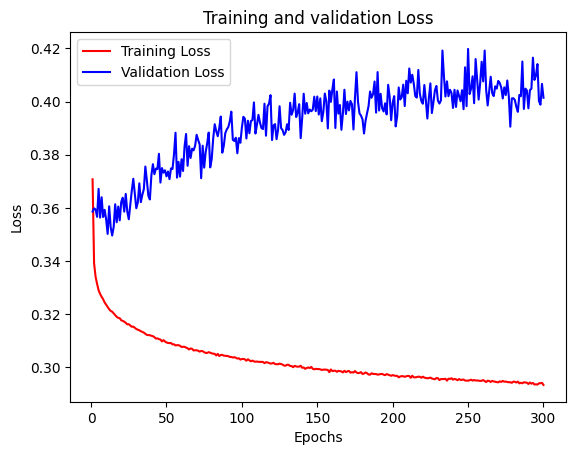

In [58]:
loss_plot(history_0)

#### Training and Validation Accuracy Plot

The code below generates a plot to visualize the accuracy of the model during training and validation phases over the epochs:
- **X-axis (Epochs)**: Represents the number of epochs (iterations) the model has trained.
  
- **Y-axis (Acc)**: Represents the accuracy of the model, indicating how well the predictions match the true labels.

- **Training Accuracy (Training Acc)**: Shows how the model’s accuracy improves on the training set.

- **Validation Accuracy (Validation Acc)**: Shows the model’s accuracy on the validation set.

In [59]:
def acc_plot(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, 'bo', label='Training Acc')
    plt.plot(epochs, val_acc, 'b', label='Validation Acc')
    plt.title('Training and validation Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Acc')
    plt.legend()
    plt.show()

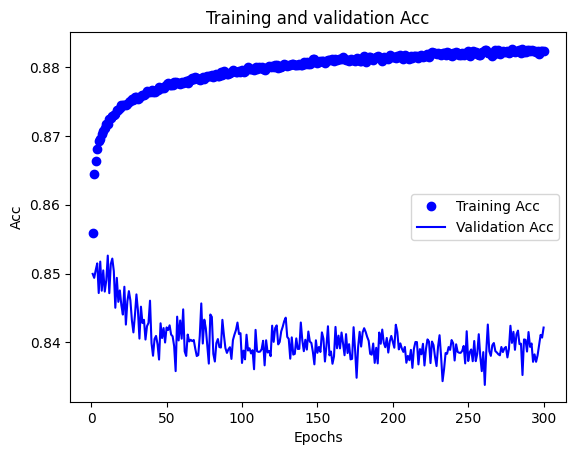

In [60]:
acc_plot(history_0)

In [61]:
x_test = np.reshape(test_set.values, (test_set.shape[0], 1, test_set.shape[1]))

In [62]:
y_pred_0 = (model_0.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_0)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 218us/step
[1 0 1 ... 0 0 0]


In [63]:
models.append(model_0)
predictions.append(y_pred_0)

In [64]:
from sklearn.metrics import classification_report

def print_report(train_label, train_predictions, validation_label, valid_predictions, v_or_t='TEST'):
    #v_or_t to print TEST or VALIDATION RESULTS
    classes=['not top20', 'top20']
    if train_label is not None:
        print('TRAINING SET RESULTS')
        print(classification_report(train_label, train_predictions, target_names=classes))
        print('--------------------')
    print(v_or_t+' SET RESULTS')
    print(classification_report(validation_label, valid_predictions, target_names=classes))

In [65]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_0)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.89      0.96      0.92     28066
       top20       0.48      0.24      0.32      4520

    accuracy                           0.86     32586
   macro avg       0.68      0.60      0.62     32586
weighted avg       0.83      0.86      0.84     32586



In [66]:
class_names = ['Class 0', 'Class 1']

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 206us/step
AUC-PR of the classifier: 0.3569
AUC-ROC of the classifier: 0.7514


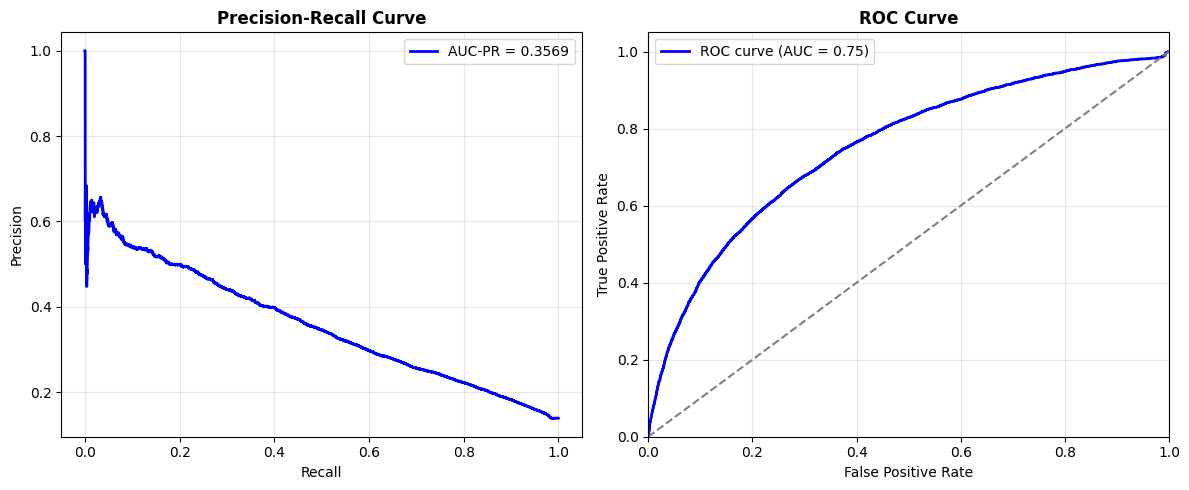

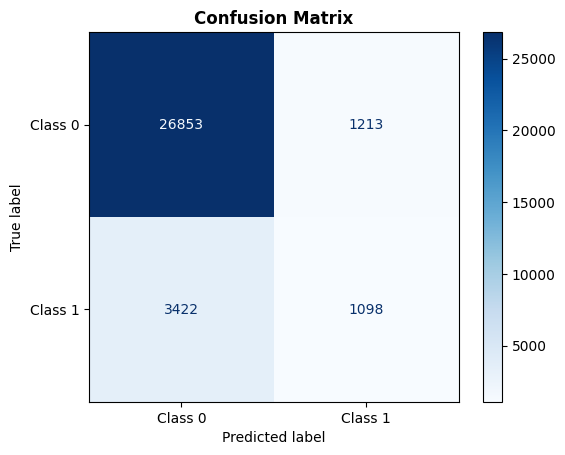

In [67]:

plot_PR_ROC_AUC(model_0, x_test, test_label)
plot_confusion_matrix_NN(test_label, y_pred_0, class_names)

Let's try the same model architecture, with same hyperparameters but without Dropout.

In [68]:
model_no_dropout = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set.shape[1])),
  keras.layers.Dense(128, activation='relu'),
  keras.layers.Dense(128, activation='relu'),
  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [69]:
history_no_dropout, model_no_dropout = fit_NN(train_set, train_label, 0.001, 2048, 300, model_no_dropout, es_p=None, weights=False)

Epoch 1/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8523 - loss: 0.3958 - val_accuracy: 0.8467 - val_loss: 0.3643
Epoch 2/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8653 - loss: 0.3357 - val_accuracy: 0.8502 - val_loss: 0.3589
Epoch 3/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.3305 - val_accuracy: 0.8495 - val_loss: 0.3597
Epoch 4/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8688 - loss: 0.3280 - val_accuracy: 0.8462 - val_loss: 0.3702
Epoch 5/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8700 - loss: 0.3260 - val_accuracy: 0.8480 - val_loss: 0.3663
Epoch 6/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3227 - val_accuracy: 0.8521 - val_loss: 0.3578
Epoch 7/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8717 - loss: 0.3226 - val_accuracy: 0.8504 - val_loss: 0.3659
Epoch 8/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8717 - loss: 0.3220 - val_accu

In [70]:
model_no_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,221 (223.52 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,148 (149.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


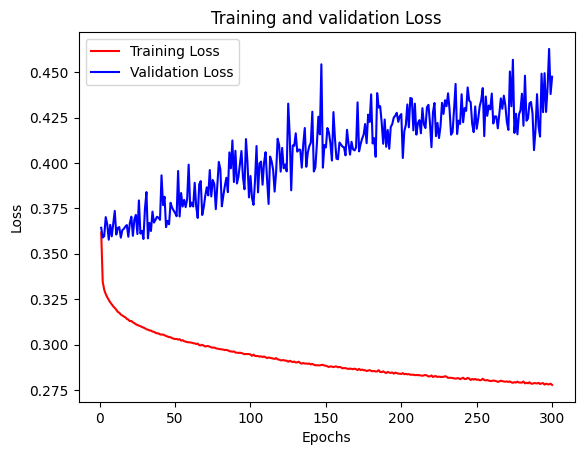

In [71]:
loss_plot(history_no_dropout)

The graph above shows that the model appears to be in *overfitting*. While the training loss decreases consistently, the validation loss starts to increase after some epochs. This suggests that the model is learning the training data too well but struggles to generalize on validation data. Therefore, reintroducing Dropout might be a suitable solution to address this issue.

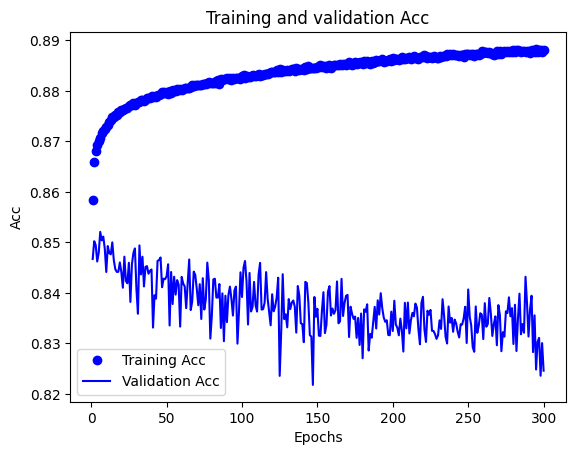

In [72]:
acc_plot(history_no_dropout)

In [73]:
y_pred_no_dropout = (model_no_dropout.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_no_dropout)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 219us/step
[1 0 1 ... 0 0 0]


In [74]:
models.append(model_no_dropout)
predictions.append(y_pred_no_dropout)

In [75]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_no_dropout)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.91      0.90     28066
       top20       0.39      0.36      0.37      4520

    accuracy                           0.83     32586
   macro avg       0.64      0.63      0.64     32586
weighted avg       0.83      0.83      0.83     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 205us/step
AUC-PR of the classifier: 0.3390
AUC-ROC of the classifier: 0.7323


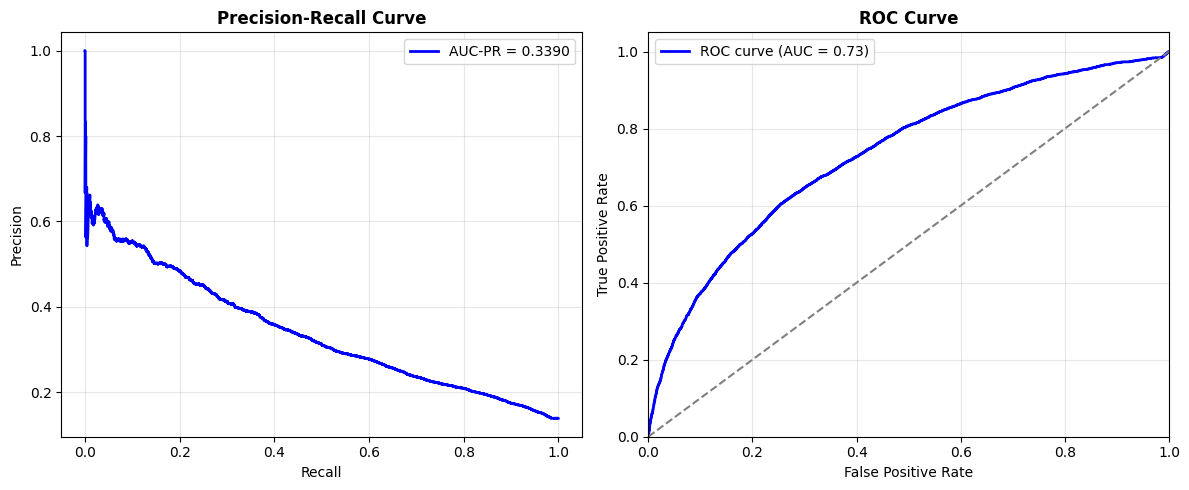

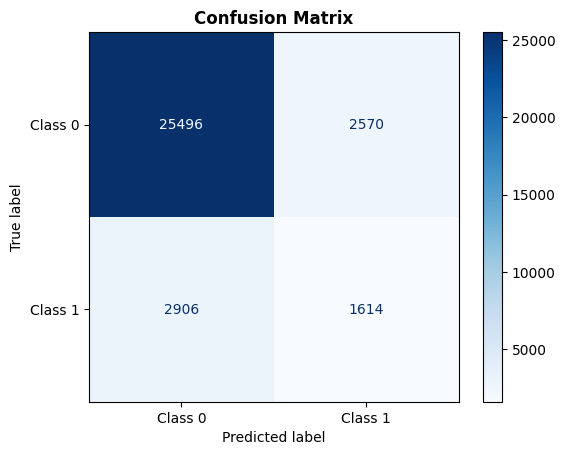

In [76]:
plot_PR_ROC_AUC(model_no_dropout, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_no_dropout, class_names= class_names)

In [77]:
model_1 = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set.shape[1])),
  keras.layers.Dense(128, activation='relu'),
  keras.layers.Dropout(0.1),
  keras.layers.Dense(128, activation='relu'),
  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [78]:
history_1, model_1 = fit_NN(train_set, train_label, 0.001, 4048, 500, model_1, es_p=None, weights=False)

Epoch 1/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8347 - loss: 0.4422 - val_accuracy: 0.8550 - val_loss: 0.3579
Epoch 2/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8605 - loss: 0.3478 - val_accuracy: 0.8527 - val_loss: 0.3563
Epoch 3/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8634 - loss: 0.3417 - val_accuracy: 0.8537 - val_loss: 0.3532
Epoch 4/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8640 - loss: 0.3382 - val_accuracy: 0.8517 - val_loss: 0.3534
Epoch 5/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8662 - loss: 0.3350 - val_accuracy: 0.8497 - val_loss: 0.3597
Epoch 6/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8672 - loss: 0.3332 - val_accuracy: 0.8501 - val_loss: 0.3585
Epoch 7/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8679 - loss: 0.3312 - val_accuracy: 0.8513 - val_loss: 0.3566
Epoch 8/500
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8687 - loss: 0.3302 - val_accuracy: 0.8506 - v

In [79]:
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,221 (223.52 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,148 (149.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


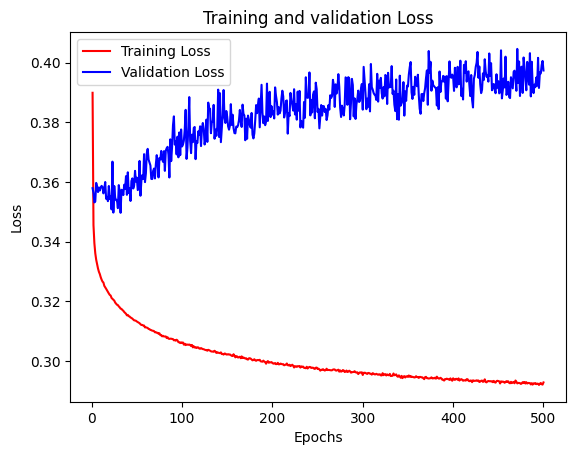

In [80]:
loss_plot(history_1)

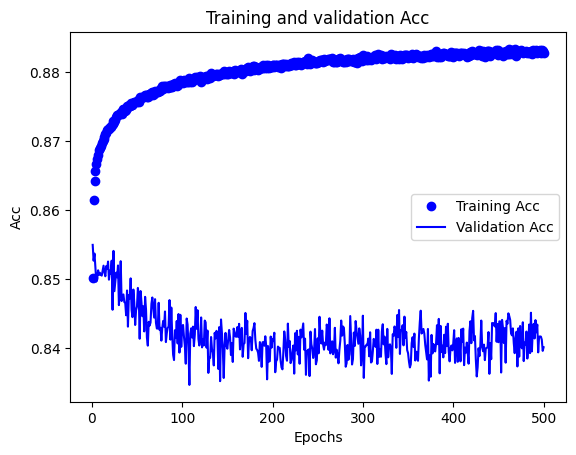

In [81]:
acc_plot(history_1)

In [82]:
y_pred_1 = (model_1.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_1)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 213us/step
[1 0 1 ... 0 0 0]


In [83]:
models.append(model_1)
predictions.append(y_pred_1)

In [84]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_1)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.89      0.95      0.92     28066
       top20       0.47      0.29      0.35      4520

    accuracy                           0.86     32586
   macro avg       0.68      0.62      0.64     32586
weighted avg       0.83      0.86      0.84     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 198us/step
AUC-PR of the classifier: 0.3638
AUC-ROC of the classifier: 0.7511


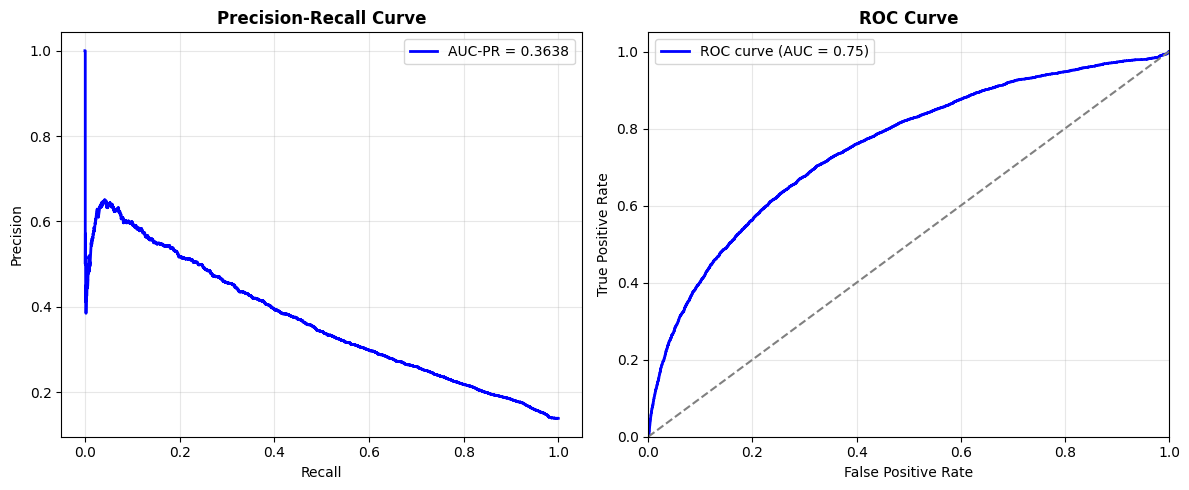

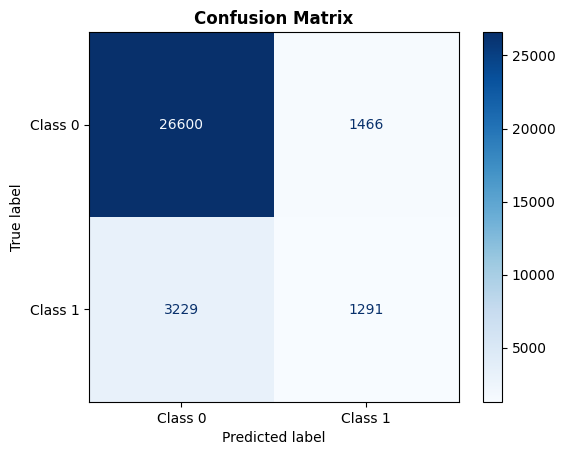

In [85]:
plot_PR_ROC_AUC(model_1, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_1, class_names= class_names)

### Models trained on the unbalanced dataset assigning weights

Here we trained different models on the unbalanced dataset, without applying any over/under sampling techniques. 
But, to reduce the impact of the unbalancing, we used *class_weights = compute_class_weight()* . The *class_weights* parameter assigns higher weights to underrepresented classes, ensuring that their misclassification has a greater impact on the loss function. 

#### A simple basic model

In [86]:
model_2 = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set.shape[1])),
  keras.layers.Dense(128, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(128, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [87]:
history_2, model_2 = fit_NN(train_set, train_label, 0.001, 2048, 300, model_2, es_p=None, weights=True)

Class weights: {0: np.float64(0.5920025644275139), 1: np.float64(3.217315561317506)}
Epoch 1/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6764 - loss: 0.5737 - val_accuracy: 0.7354 - val_loss: 0.5474
Epoch 2/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7322 - loss: 0.5274 - val_accuracy: 0.7352 - val_loss: 0.5592
Epoch 3/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7409 - loss: 0.5207 - val_accuracy: 0.6998 - val_loss: 0.6234
Epoch 4/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7397 - loss: 0.5183 - val_accuracy: 0.7304 - val_loss: 0.5895
Epoch 5/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7449 - loss: 0.5155 - val_accuracy: 0.7442 - val_loss: 0.5658
Epoch 6/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7463 - loss: 0.5125 - val_accuracy: 0.7472 - val_loss: 0.5601
Epoch 7/300
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7522 - loss: 0.5099 - val_accuracy: 0.7293 - val_loss: 0.5922
Epoch 8/300


In [88]:
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,221 (223.52 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,148 (149.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


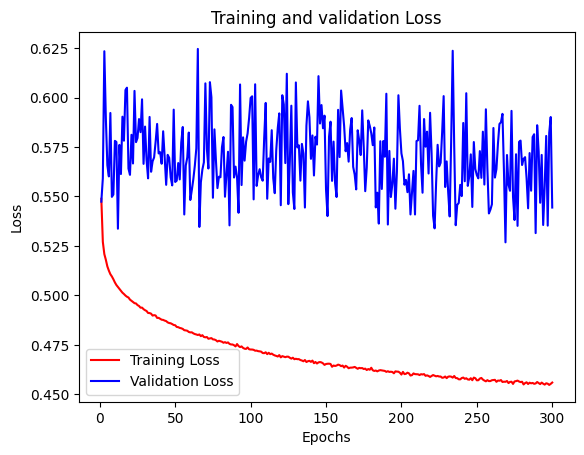

In [89]:
loss_plot(history_2)

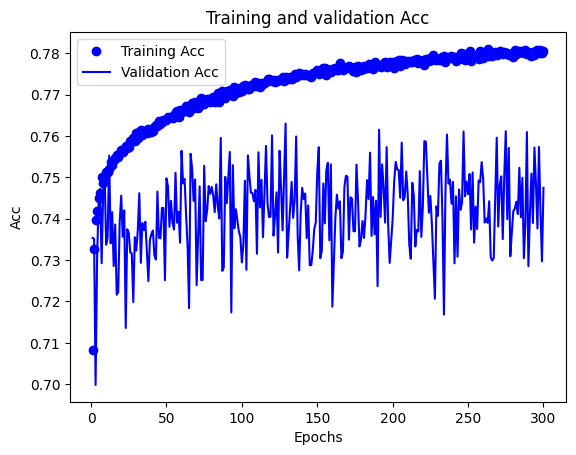

In [90]:
acc_plot(history_2)

In [91]:
y_pred_2 = (model_2.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_2)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 205us/step
[1 0 1 ... 0 0 0]


In [92]:
models.append(model_2)
predictions.append(y_pred_2)

In [93]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_2)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.78      0.84     28066
       top20       0.30      0.59      0.40      4520

    accuracy                           0.75     32586
   macro avg       0.61      0.68      0.62     32586
weighted avg       0.83      0.75      0.78     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 202us/step
AUC-PR of the classifier: 0.3487
AUC-ROC of the classifier: 0.7458


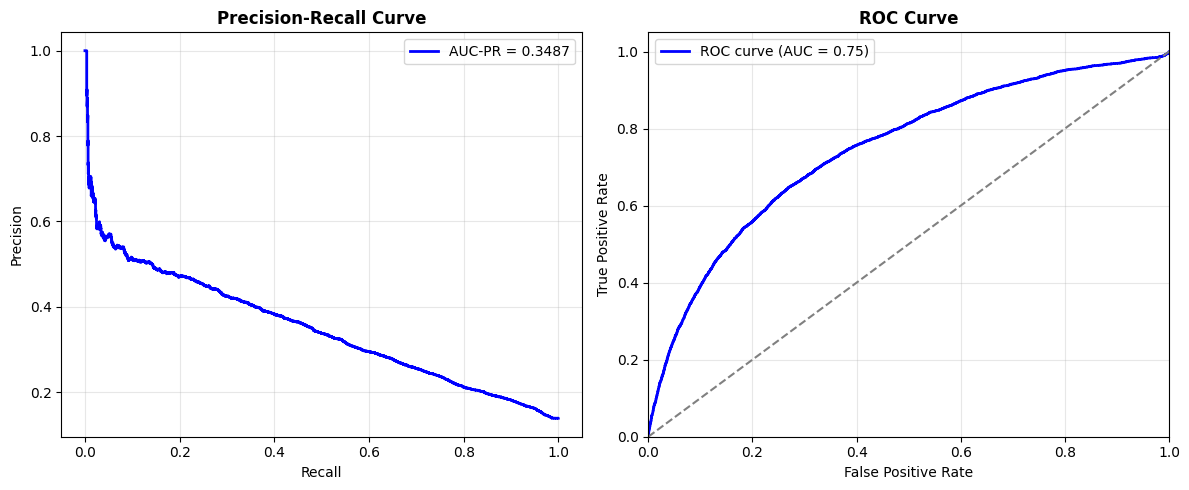

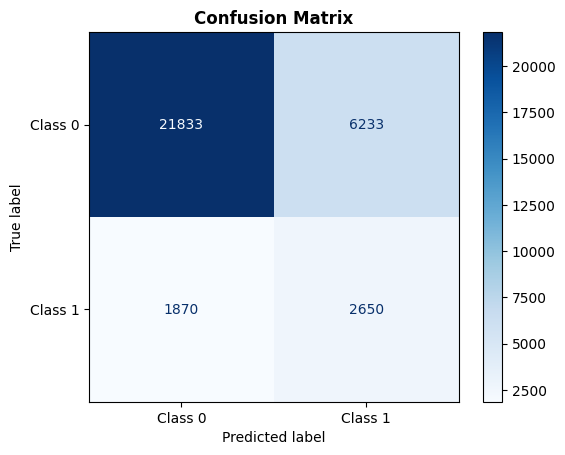

In [94]:
plot_PR_ROC_AUC(model_2, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_2, class_names= class_names)

We try with the same model architecture but using larger number of epochs and larger batch size. Since the dataset is huge, we can try to incrase the batch size. This can help to reduce noise in the validation loss by providing a more accurate estimation of the gradients during training. Larger batches may reduce variance in gradient updates, leading to smoother and more stable validation loss curves. 

In [95]:
model_3 = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set.shape[1])),
  keras.layers.Dense(128, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(128, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [96]:
history_3, model_3 = fit_NN(train_set, train_label, 0.001, 4096, 500, model_3, es_p=None, weights=True)

Class weights: {0: np.float64(0.5920025644275139), 1: np.float64(3.217315561317506)}
Epoch 1/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6167 - loss: 0.6013 - val_accuracy: 0.7161 - val_loss: 0.5686
Epoch 2/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7291 - loss: 0.5306 - val_accuracy: 0.7380 - val_loss: 0.5486
Epoch 3/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7342 - loss: 0.5255 - val_accuracy: 0.7315 - val_loss: 0.5736
Epoch 4/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7395 - loss: 0.5213 - val_accuracy: 0.7393 - val_loss: 0.5677
Epoch 5/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7405 - loss: 0.5183 - val_accuracy: 0.7330 - val_loss: 0.5769
Epoch 6/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7439 - loss: 0.5174 - val_accuracy: 0.7376 - val_loss: 0.5698
Epoch 7/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7454 - loss: 0.5162 - val_accuracy: 0.7277 - val_loss: 0.5857
Epoch 8/500
94/94 ━━━━━━━━

In [97]:
model_3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,221 (223.52 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,148 (149.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


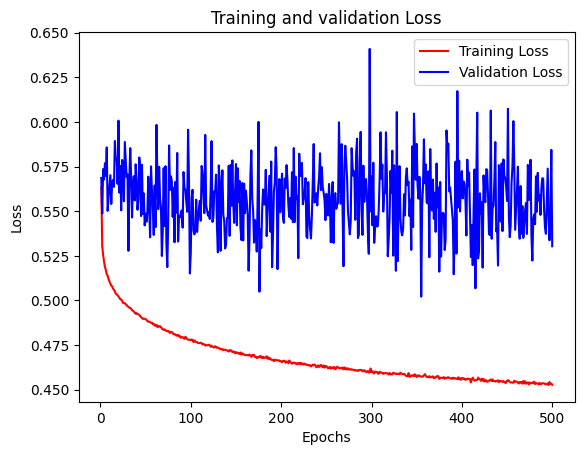

In [98]:
loss_plot(history_3)

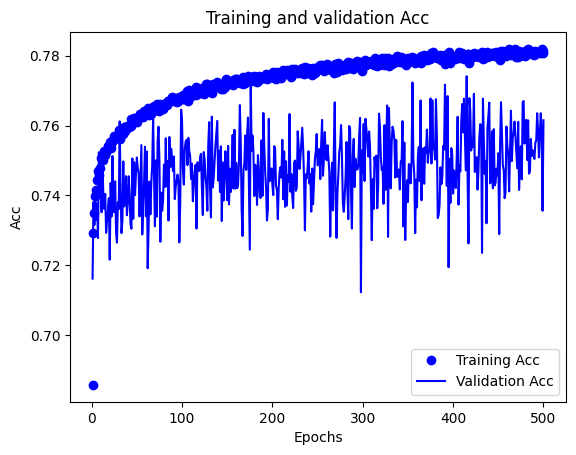

In [99]:
acc_plot(history_3)

In [100]:
y_pred_3 = (model_3.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_3)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 212us/step
[1 1 1 ... 1 0 0]


In [101]:
models.append(model_3)
predictions.append(y_pred_3)

In [102]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_3)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.81      0.86     28066
       top20       0.32      0.56      0.40      4520

    accuracy                           0.77     32586
   macro avg       0.62      0.68      0.63     32586
weighted avg       0.84      0.77      0.80     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 203us/step
AUC-PR of the classifier: 0.3613
AUC-ROC of the classifier: 0.7527


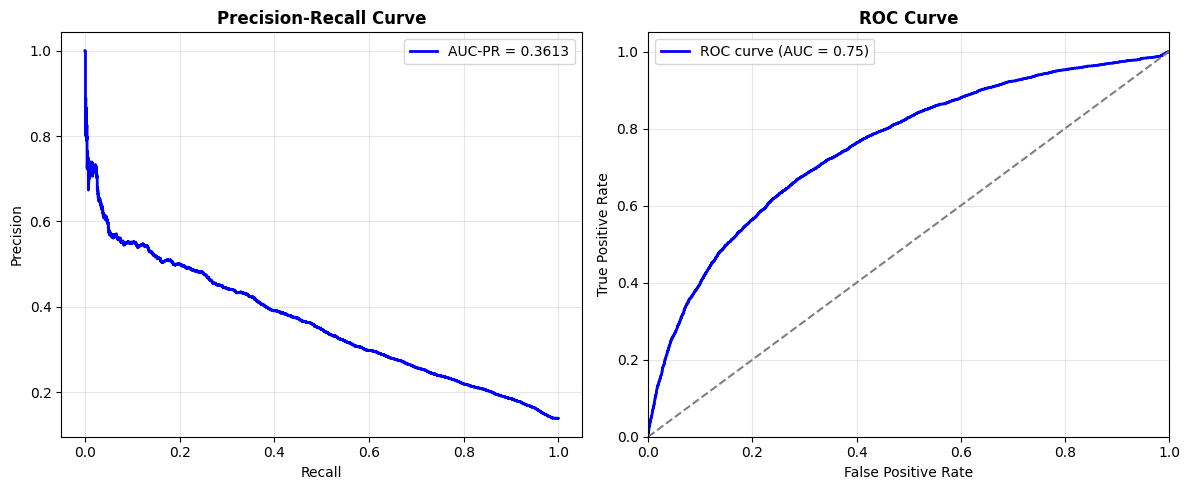

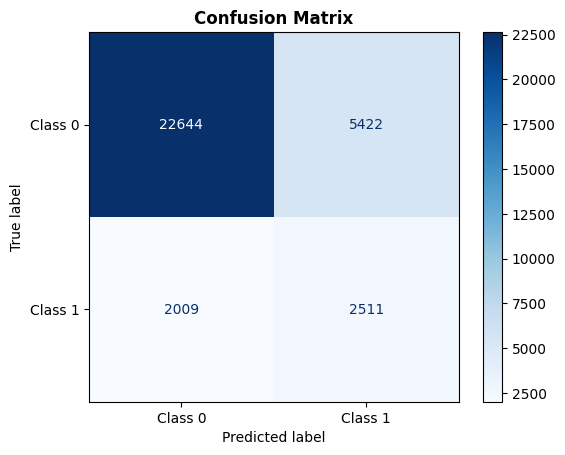

In [103]:
plot_PR_ROC_AUC(model_3, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_3, class_names= class_names)

### Models trained on training set oversampled with SMOTE

In [104]:
model_0_sm  = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set_smote.shape[1])),
  keras.layers.Dense(128, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(128, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [105]:
history_0_sm, model_0_sm = fit_NN(train_set_smote, train_label_smote, 0.001, 2048, 500, model_0_sm, es_p=None, weights=False)

Epoch 1/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7641 - loss: 0.4973 - val_accuracy: 0.4319 - val_loss: 0.9589
Epoch 2/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8029 - loss: 0.4323 - val_accuracy: 0.4107 - val_loss: 1.0045
Epoch 3/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8057 - loss: 0.4256 - val_accuracy: 0.4035 - val_loss: 1.0100
Epoch 4/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8080 - loss: 0.4211 - val_accuracy: 0.4273 - val_loss: 0.9686
Epoch 5/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8093 - loss: 0.4194 - val_accuracy: 0.3986 - val_loss: 1.0268
Epoch 6/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8097 - loss: 0.4178 - val_accuracy: 0.4421 - val_loss: 0.9296
Epoch 7/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8110 - loss: 0.4149 - val_accuracy: 0.4199 - val_loss: 0.9851
Epoch 8/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8130 - loss: 0.4131 - val_accu

In [106]:
model_0_sm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,221 (223.52 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,148 (149.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


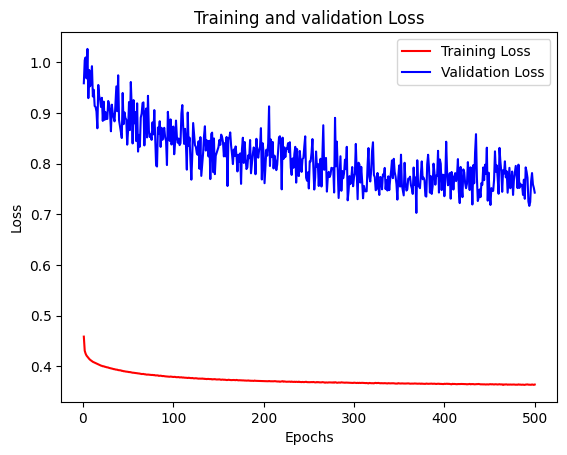

In [107]:
loss_plot(history_0_sm)

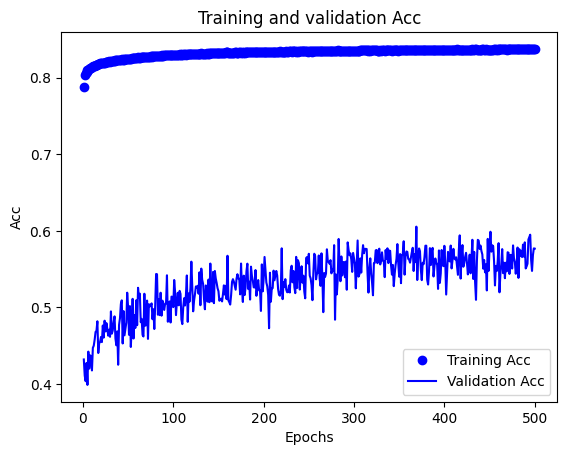

In [108]:
acc_plot(history_0_sm)

In [109]:
y_pred_0_sm = (model_0_sm.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_0_sm)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 210us/step
[1 0 1 ... 0 0 0]


In [110]:
models.append(model_0_sm)
predictions.append(y_pred_0_sm)

In [111]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_0_sm)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.92      0.91     28066
       top20       0.42      0.35      0.38      4520

    accuracy                           0.84     32586
   macro avg       0.66      0.64      0.65     32586
weighted avg       0.83      0.84      0.84     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 199us/step
AUC-PR of the classifier: 0.3584
AUC-ROC of the classifier: 0.7455


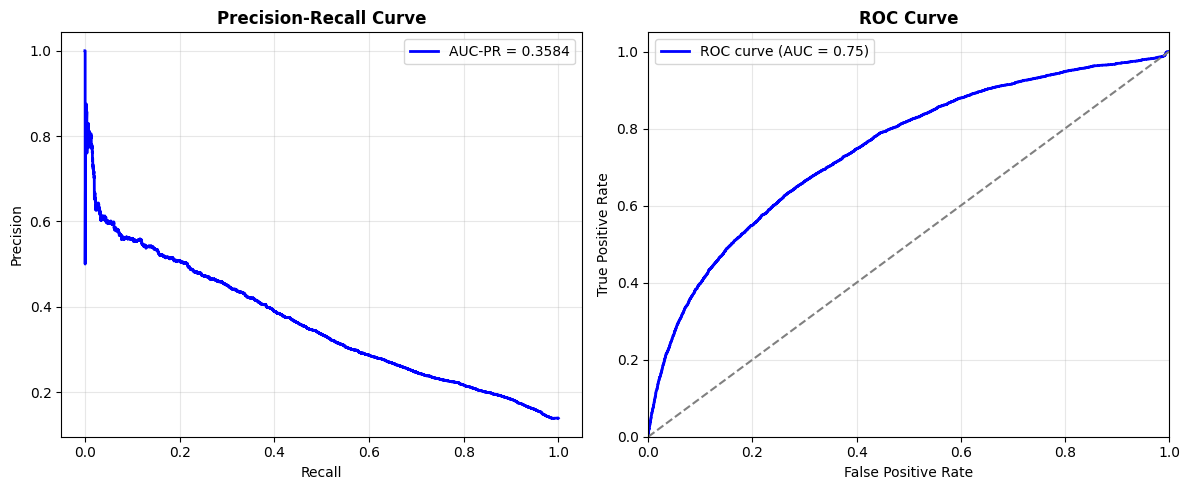

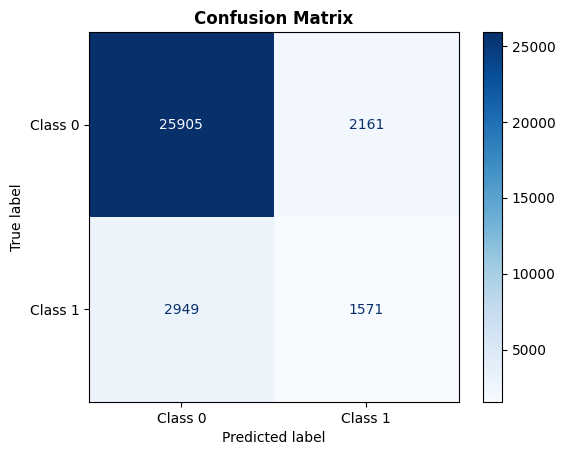

In [112]:
plot_PR_ROC_AUC(model_0_sm, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_0_sm, class_names= class_names)

Let's try to increase the batch size

In [113]:
model_1_sm  = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set_smote.shape[1])),
  keras.layers.Dense(128, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(128, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [114]:
history_1_sm, model_1_sm = fit_NN(train_set_smote, train_label_smote, 0.001, 4096, 500, model_1_sm, es_p=None, weights=False)

Epoch 1/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7717 - loss: 0.5000 - val_accuracy: 0.4026 - val_loss: 1.0080
Epoch 2/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8013 - loss: 0.4339 - val_accuracy: 0.4327 - val_loss: 0.9648
Epoch 3/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8030 - loss: 0.4298 - val_accuracy: 0.4498 - val_loss: 0.9409
Epoch 4/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8076 - loss: 0.4232 - val_accuracy: 0.4604 - val_loss: 0.9236
Epoch 5/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8073 - loss: 0.4222 - val_accuracy: 0.4235 - val_loss: 0.9816
Epoch 6/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8096 - loss: 0.4190 - val_accuracy: 0.4376 - val_loss: 0.9597
Epoch 7/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8106 - loss: 0.4170 - val_accuracy: 0.4157 - val_loss: 1.0122
Epoch 8/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8115 - loss: 0.4154 - val_accu

In [115]:
model_1_sm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,221 (223.52 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,148 (149.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


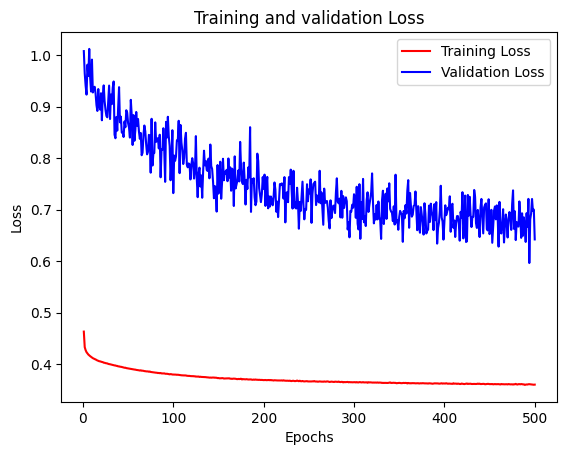

In [116]:
loss_plot(history_1_sm)

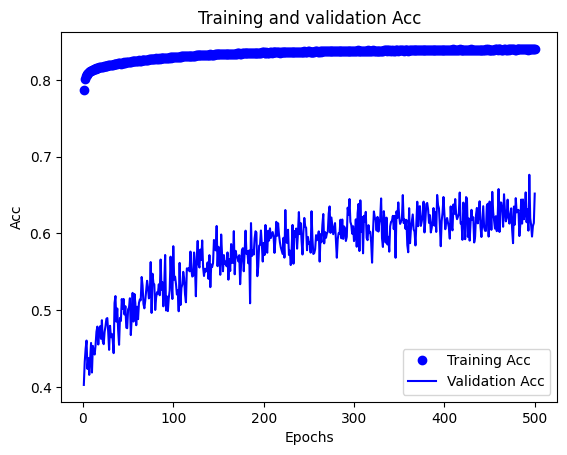

In [117]:
acc_plot(history_1_sm)

In [118]:
y_pred_1_sm = (model_1_sm.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_1_sm)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 210us/step
[1 0 1 ... 1 0 0]


In [119]:
models.append(model_1_sm)
predictions.append(y_pred_1_sm)

In [120]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_1_sm)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.90      0.90     28066
       top20       0.39      0.40      0.39      4520

    accuracy                           0.83     32586
   macro avg       0.65      0.65      0.65     32586
weighted avg       0.83      0.83      0.83     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 202us/step
AUC-PR of the classifier: 0.3612
AUC-ROC of the classifier: 0.7406


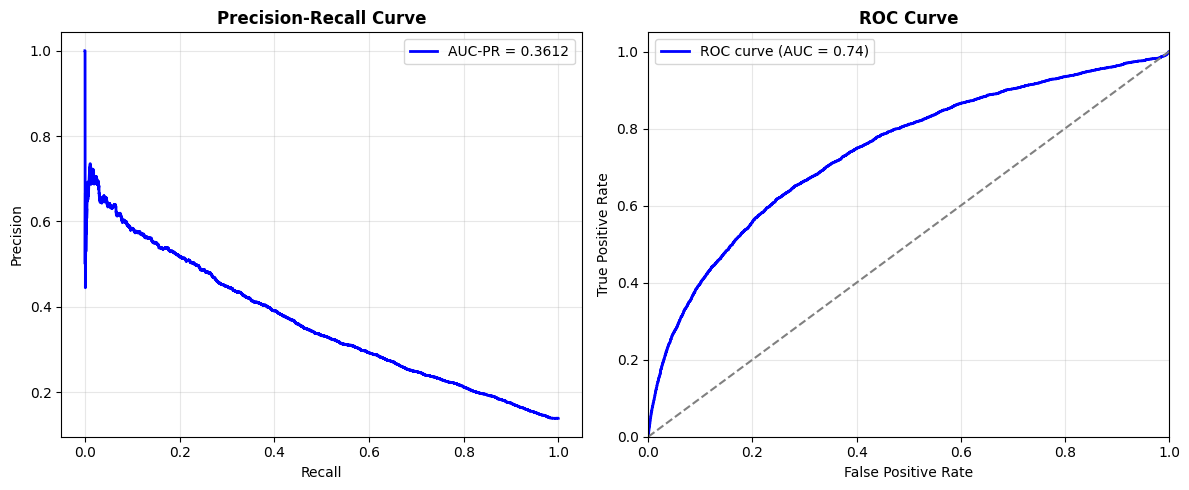

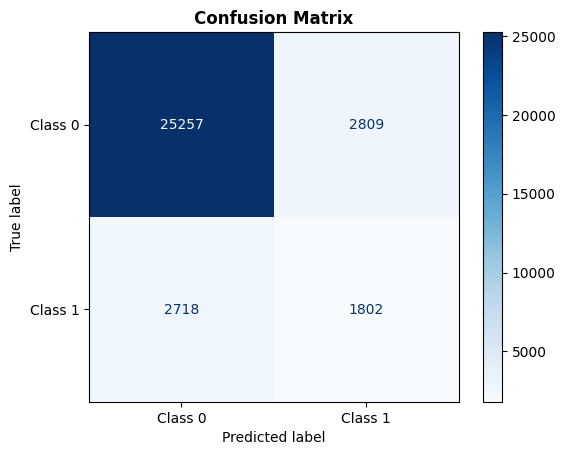

In [121]:
plot_PR_ROC_AUC(model_1_sm, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_1_sm, class_names= class_names)

In [122]:
model_2_sm  = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set_smote.shape[1])),
  keras.layers.Dense(256, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(256, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [123]:
history_2_sm, model_2_sm = fit_NN(train_set_smote, train_label_smote, 0.001, 4096, 500, model_2_sm, es_p=None, weights=False)

Epoch 1/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7607 - loss: 0.4968 - val_accuracy: 0.4082 - val_loss: 0.9883
Epoch 2/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8026 - loss: 0.4304 - val_accuracy: 0.4184 - val_loss: 0.9797
Epoch 3/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8059 - loss: 0.4253 - val_accuracy: 0.4192 - val_loss: 0.9928
Epoch 4/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8096 - loss: 0.4194 - val_accuracy: 0.4408 - val_loss: 0.9581
Epoch 5/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8112 - loss: 0.4166 - val_accuracy: 0.4451 - val_loss: 0.9534
Epoch 6/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8124 - loss: 0.4128 - val_accuracy: 0.4694 - val_loss: 0.8840
Epoch 7/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8141 - loss: 0.4106 - val_accuracy: 0.4888 - val_loss: 0.8607
Epoch 8/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8137 - loss: 0.4099 - val_accu

In [124]:
model_2_sm.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,741 (831.02 KB)

 Trainable params: 70,913 (277.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 141,828 (554.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


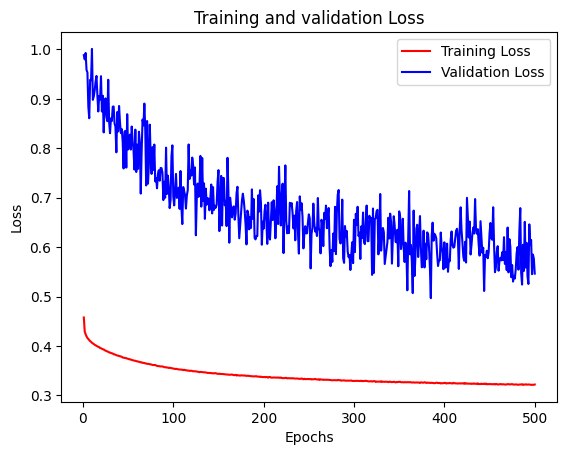

In [125]:
loss_plot(history_2_sm)

As we can see here, the validation loss increases rather than decreases, indicating that the model is likely starting to overfit. Therefore, adding Dropout may be necessary to improve generalization.

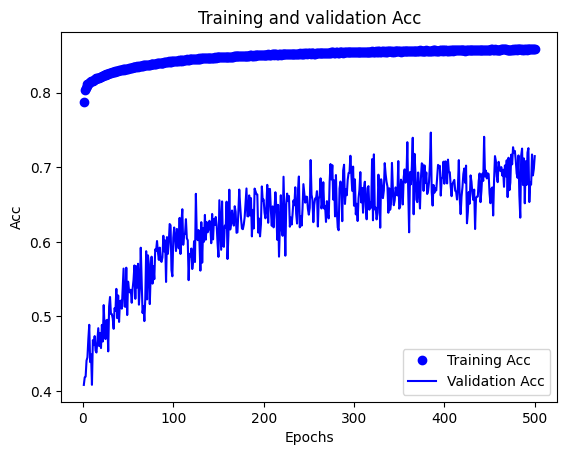

In [126]:
acc_plot(history_2_sm)

In [127]:
y_pred_2_sm = (model_2_sm.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_2_sm)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step
[1 0 1 ... 1 0 0]


In [128]:
models.append(model_2_sm)
predictions.append(y_pred_2_sm)

In [129]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_2_sm)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.91      0.90     28066
       top20       0.39      0.38      0.39      4520

    accuracy                           0.83     32586
   macro avg       0.65      0.64      0.64     32586
weighted avg       0.83      0.83      0.83     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step
AUC-PR of the classifier: 0.3453
AUC-ROC of the classifier: 0.7342


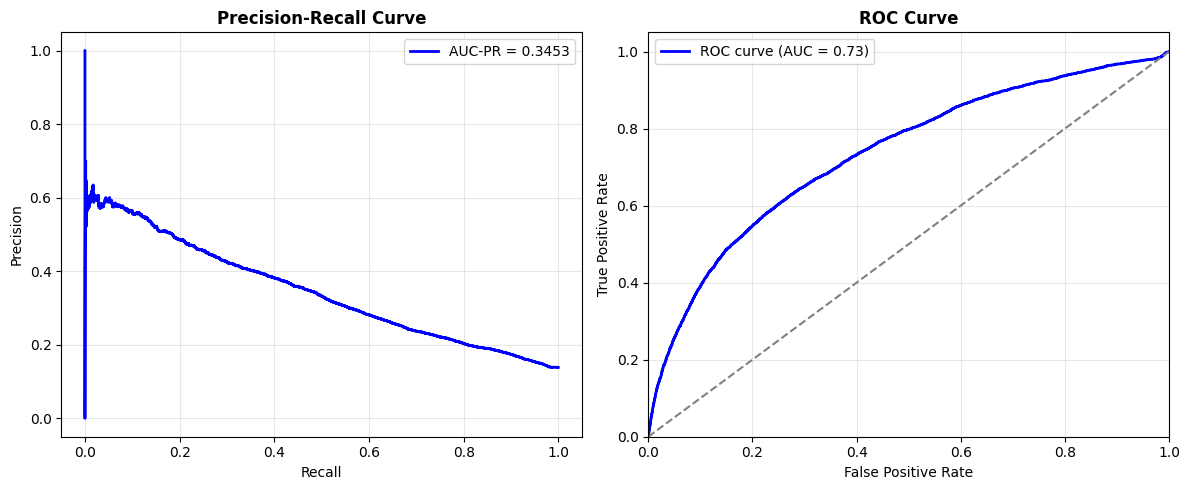

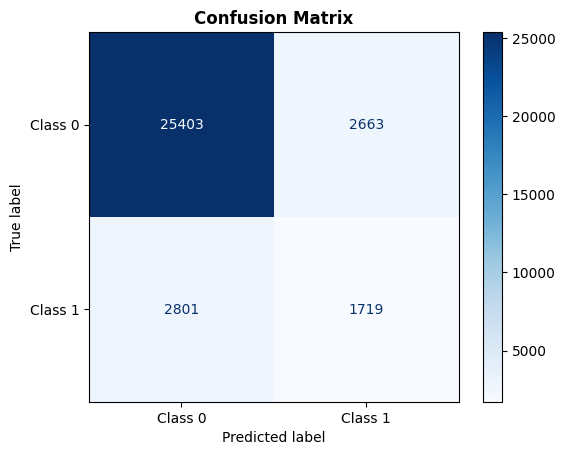

In [130]:
plot_PR_ROC_AUC(model_2_sm, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_2_sm, class_names= class_names)

In [131]:
model_3_sm  = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set_smote.shape[1])),
  keras.layers.Dense(256, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(512, activation='relu'),
  keras.layers.Dropout(0.1),
  keras.layers.Dense(256, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [132]:
history_3_sm, model_3_sm = fit_NN(train_set_smote, train_label_smote, 0.001, 4096, 500, model_3_sm, es_p=None, weights=False)

Epoch 1/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7761 - loss: 0.4813 - val_accuracy: 0.4380 - val_loss: 0.9784
Epoch 2/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8051 - loss: 0.4271 - val_accuracy: 0.4361 - val_loss: 0.9866
Epoch 3/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8091 - loss: 0.4194 - val_accuracy: 0.4717 - val_loss: 0.9148
Epoch 4/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8119 - loss: 0.4135 - val_accuracy: 0.4410 - val_loss: 0.9309
Epoch 5/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8153 - loss: 0.4083 - val_accuracy: 0.4512 - val_loss: 0.9136
Epoch 6/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8150 - loss: 0.4082 - val_accuracy: 0.4934 - val_loss: 0.8709
Epoch 7/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8169 - loss: 0.4054 - val_accuracy: 0.4846 - val_loss: 0.8626
Epoch 8/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8188 - loss: 0.4006 - 

In [133]:
model_3_sm.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,101 (3.07 MB)

 Trainable params: 268,033 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 536,068 (2.04 MB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


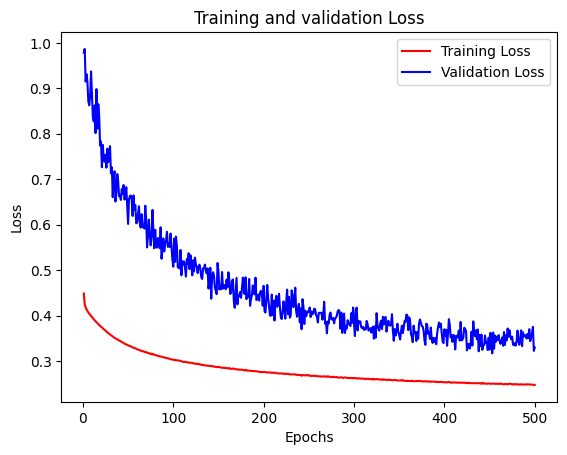

In [134]:
loss_plot(history_3_sm)

As we can see here, the validation loss increases rather than decreases, indicating that the model is likely starting to overfit. Therefore, adding Dropout may be necessary to improve generalization.

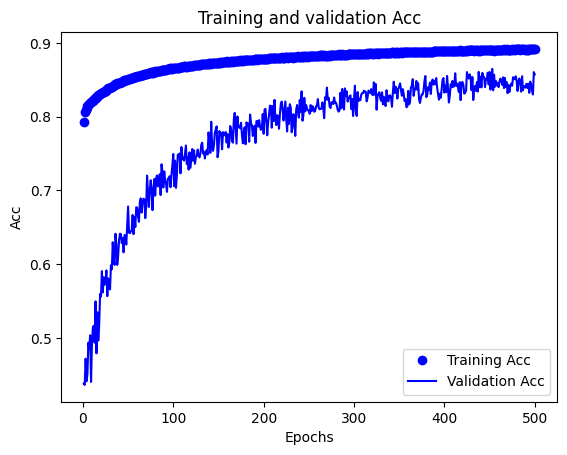

In [135]:
acc_plot(history_3_sm)

In [136]:
y_pred_3_sm = (model_3_sm.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_3_sm)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step
[1 0 1 ... 1 0 0]


In [137]:
models.append(model_3_sm)
predictions.append(y_pred_3_sm)

In [138]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_3_sm)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.90      0.90     28066
       top20       0.37      0.35      0.36      4520

    accuracy                           0.83     32586
   macro avg       0.63      0.62      0.63     32586
weighted avg       0.82      0.83      0.82     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step
AUC-PR of the classifier: 0.3306
AUC-ROC of the classifier: 0.7237


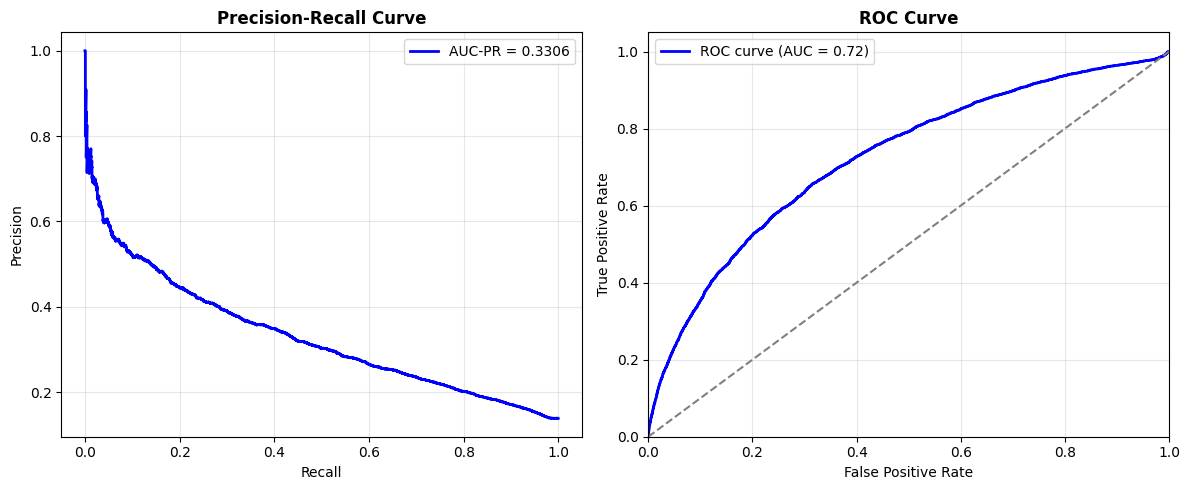

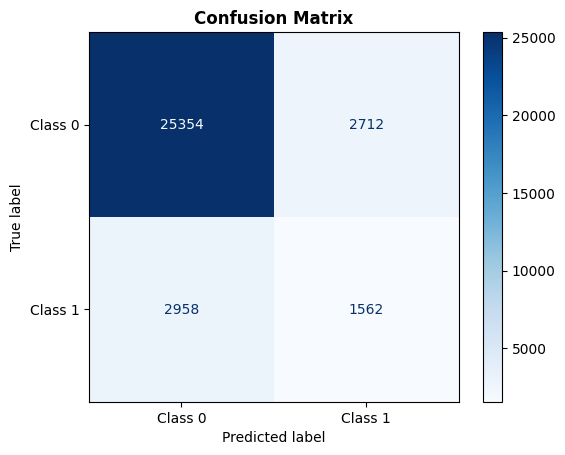

In [139]:
plot_PR_ROC_AUC(model_3_sm, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_3_sm, class_names= class_names)

### Models trained on training set oversampled with Randomsampling

In [140]:
model_0_os  = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set_os.shape[1])),
  keras.layers.Dense(128, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(128, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [141]:
history_0_os, model_0_os = fit_NN(train_set_os, train_label_os, 0.001, 2048, 500, model_0_os, es_p=None, weights=False)

Epoch 1/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7653 - loss: 0.4945 - val_accuracy: 0.4268 - val_loss: 0.9736
Epoch 2/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8031 - loss: 0.4323 - val_accuracy: 0.4290 - val_loss: 0.9757
Epoch 3/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8059 - loss: 0.4281 - val_accuracy: 0.3954 - val_loss: 1.0386
Epoch 4/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8087 - loss: 0.4231 - val_accuracy: 0.4027 - val_loss: 1.0126
Epoch 5/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8101 - loss: 0.4206 - val_accuracy: 0.4182 - val_loss: 1.0000
Epoch 6/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8104 - loss: 0.4200 - val_accuracy: 0.4106 - val_loss: 0.9958
Epoch 7/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8116 - loss: 0.4169 - val_accuracy: 0.4114 - val_loss: 1.0122
Epoch 8/500
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8125 - loss: 0.4153 - val_accu

In [142]:
model_0_os.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,221 (223.52 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,148 (149.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


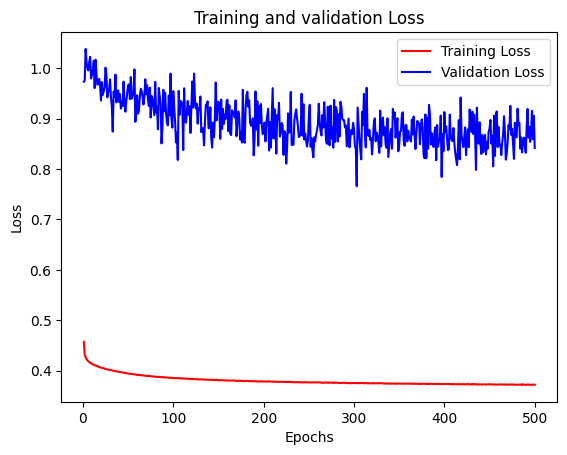

In [143]:
loss_plot(history_0_os)

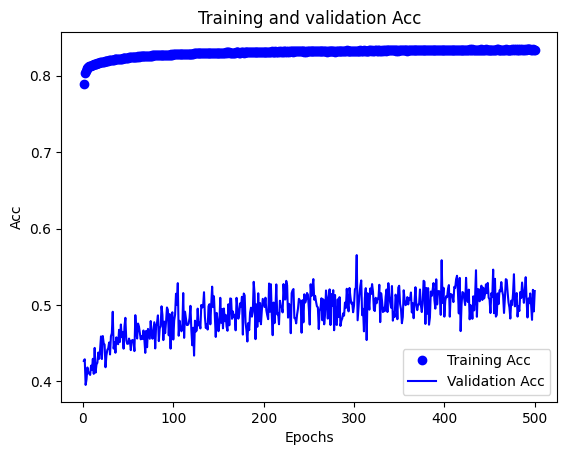

In [144]:
acc_plot(history_0_os)

In [145]:
y_pred_0_os = (model_0_os.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_0_os)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step
[1 0 1 ... 0 0 0]


In [146]:
models.append(model_0_os)
predictions.append(y_pred_0_os)

In [147]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_0_os)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.89      0.90     28066
       top20       0.39      0.42      0.40      4520

    accuracy                           0.83     32586
   macro avg       0.65      0.66      0.65     32586
weighted avg       0.83      0.83      0.83     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 234us/step
AUC-PR of the classifier: 0.3714
AUC-ROC of the classifier: 0.7483


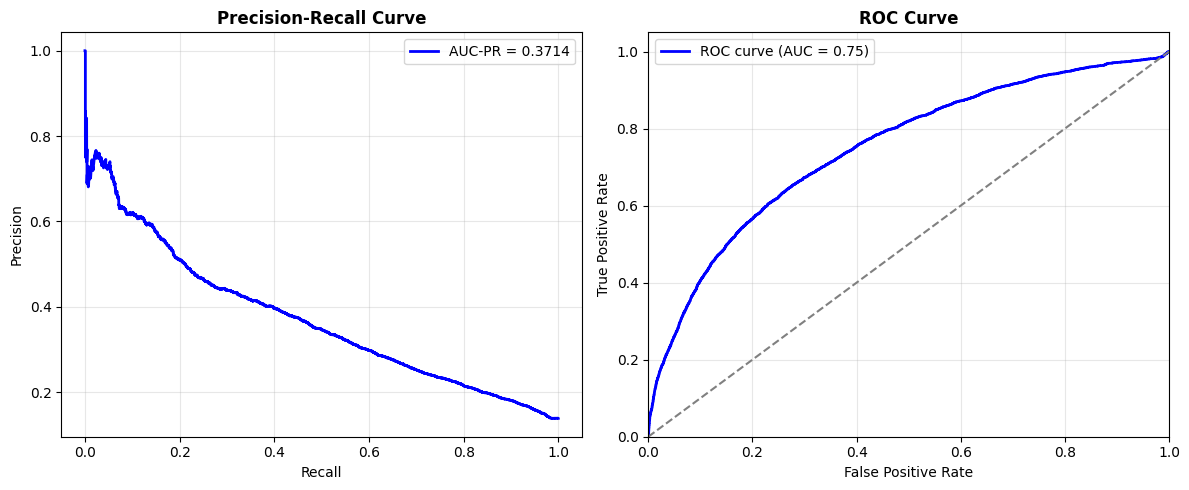

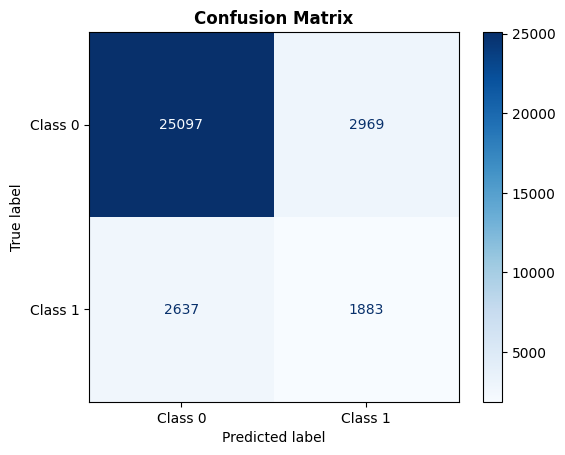

In [148]:
plot_PR_ROC_AUC(model_0_os, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_0_os, class_names= class_names)

In [149]:
model_1_os  = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set_smote.shape[1])),
  keras.layers.Dense(256, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(256, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [150]:
history_1_os, model_1_os = fit_NN(train_set_smote, train_label_smote, 0.001, 4096, 500, model_1_os, es_p=None, weights=False)

Epoch 1/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7775 - loss: 0.4871 - val_accuracy: 0.4276 - val_loss: 0.9703
Epoch 2/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8041 - loss: 0.4288 - val_accuracy: 0.4099 - val_loss: 0.9977
Epoch 3/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8067 - loss: 0.4239 - val_accuracy: 0.4550 - val_loss: 0.9265
Epoch 4/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8096 - loss: 0.4183 - val_accuracy: 0.4460 - val_loss: 0.9498
Epoch 5/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8115 - loss: 0.4151 - val_accuracy: 0.4343 - val_loss: 0.9634
Epoch 6/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8125 - loss: 0.4136 - val_accuracy: 0.4513 - val_loss: 0.9483
Epoch 7/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8137 - loss: 0.4109 - val_accuracy: 0.4562 - val_loss: 0.9215
Epoch 8/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8140 - loss: 0.4100 - val_accu

In [151]:
model_1_os.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,741 (831.02 KB)

 Trainable params: 70,913 (277.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 141,828 (554.02 KB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


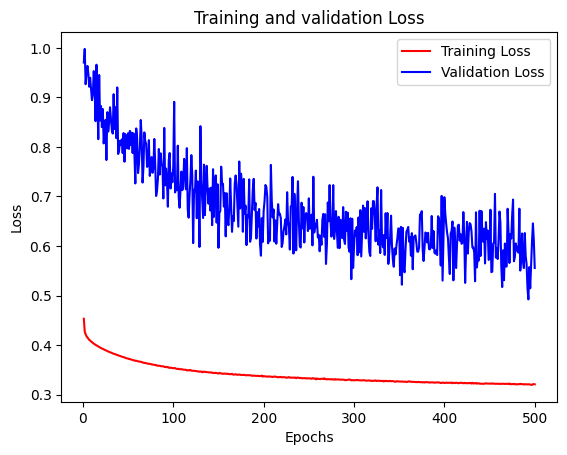

In [152]:
loss_plot(history_1_os)

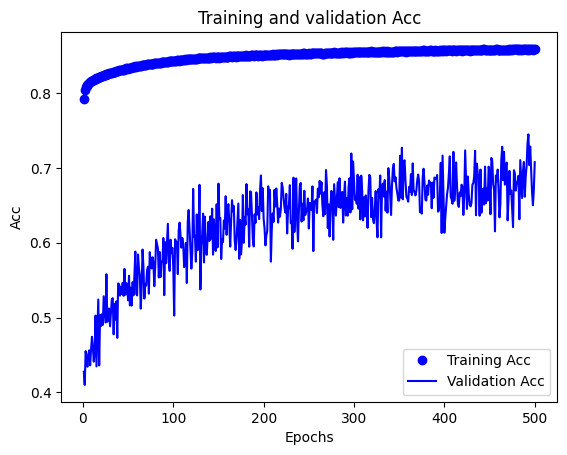

In [153]:
acc_plot(history_1_os)

In [154]:
y_pred_1_os = (model_1_os.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_1_os)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step
[1 0 1 ... 0 0 0]


In [155]:
models.append(model_1_os)
predictions.append(y_pred_1_os)

In [156]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_1_os)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.90      0.90     28066
       top20       0.38      0.36      0.37      4520

    accuracy                           0.83     32586
   macro avg       0.64      0.63      0.64     32586
weighted avg       0.83      0.83      0.83     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 244us/step
AUC-PR of the classifier: 0.3415
AUC-ROC of the classifier: 0.7371


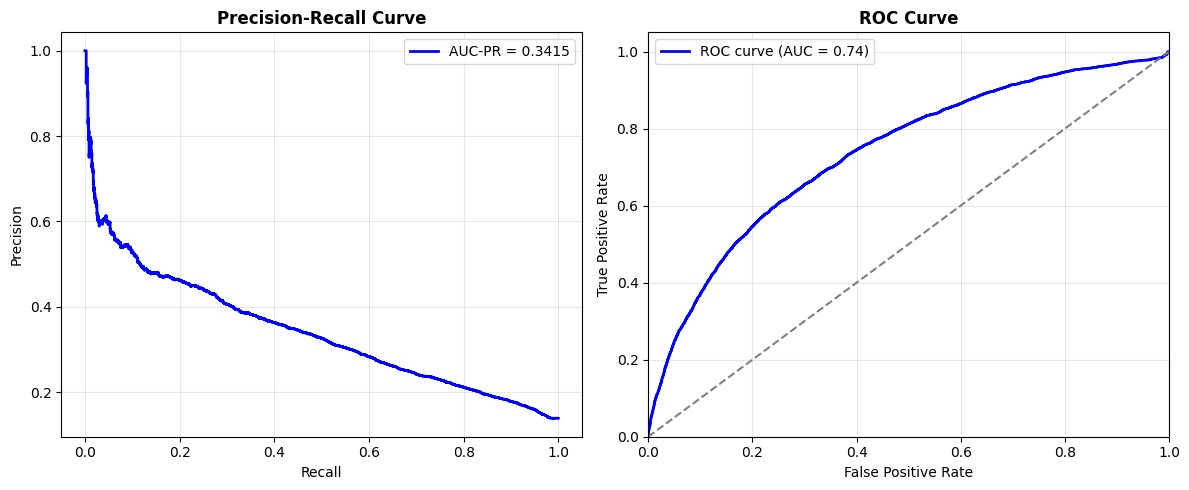

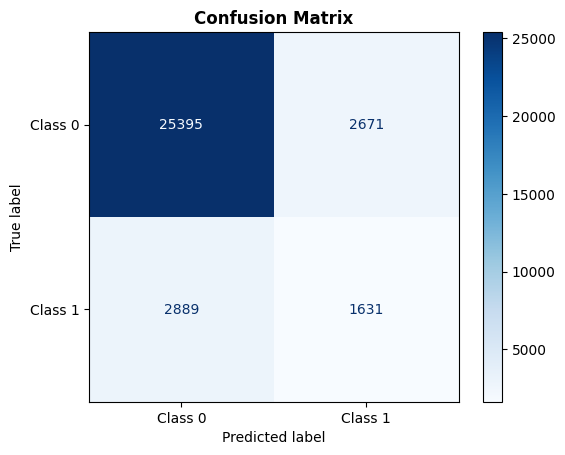

In [157]:
plot_PR_ROC_AUC(model_1_os, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_1_os, class_names= class_names)

In [158]:
model_2_os  = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set_smote.shape[1])),
  keras.layers.Dense(256, activation='relu'),
 
  keras.layers.Dropout(0.1),
  keras.layers.Dense(512, activation='relu'),
  keras.layers.Dropout(0.1),
  keras.layers.Dense(256, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [159]:
history_2_os, model_2_os = fit_NN(train_set_smote, train_label_smote, 0.001, 4096, 300, model_2_os, es_p=None, weights=False)

Epoch 1/300
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7677 - loss: 0.4825 - val_accuracy: 0.4220 - val_loss: 0.9902
Epoch 2/300
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8067 - loss: 0.4248 - val_accuracy: 0.4767 - val_loss: 0.8991
Epoch 3/300
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8107 - loss: 0.4173 - val_accuracy: 0.4611 - val_loss: 0.8968
Epoch 4/300
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8123 - loss: 0.4136 - val_accuracy: 0.4514 - val_loss: 0.9153
Epoch 5/300
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8145 - loss: 0.4092 - val_accuracy: 0.4552 - val_loss: 0.9160
Epoch 6/300
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8167 - loss: 0.4059 - val_accuracy: 0.4363 - val_loss: 0.9606
Epoch 7/300
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8174 - loss: 0.4044 - val_accuracy: 0.5134 - val_loss: 0.8354
Epoch 8/300
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8192 - loss: 0.4001 - 

In [160]:
model_2_os.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,101 (3.07 MB)

 Trainable params: 268,033 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 536,068 (2.04 MB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


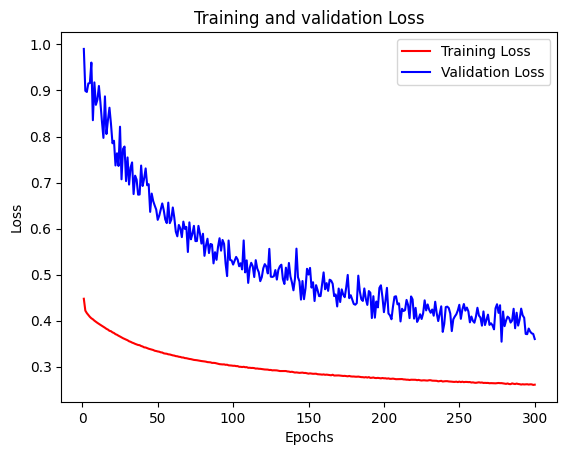

In [161]:
loss_plot(history_2_os)

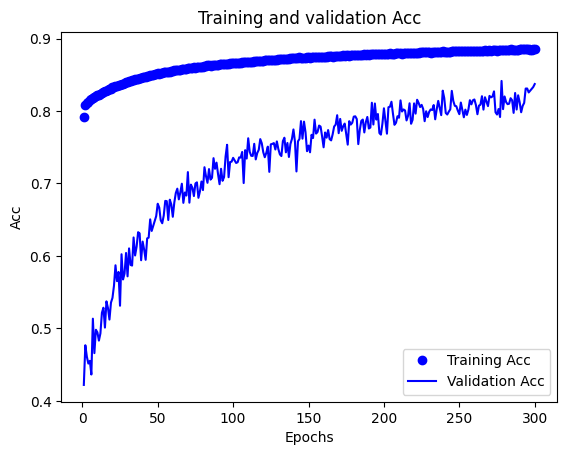

In [162]:
acc_plot(history_2_os)

In [163]:
y_pred_2_os = (model_2_os.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_2_os)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step
[1 0 1 ... 1 0 0]


In [164]:
models.append(model_2_os)
predictions.append(y_pred_2_os)

In [165]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_2_os)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.89      0.92      0.91     28066
       top20       0.38      0.31      0.34      4520

    accuracy                           0.83     32586
   macro avg       0.64      0.61      0.62     32586
weighted avg       0.82      0.83      0.83     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step
AUC-PR of the classifier: 0.3269
AUC-ROC of the classifier: 0.7144


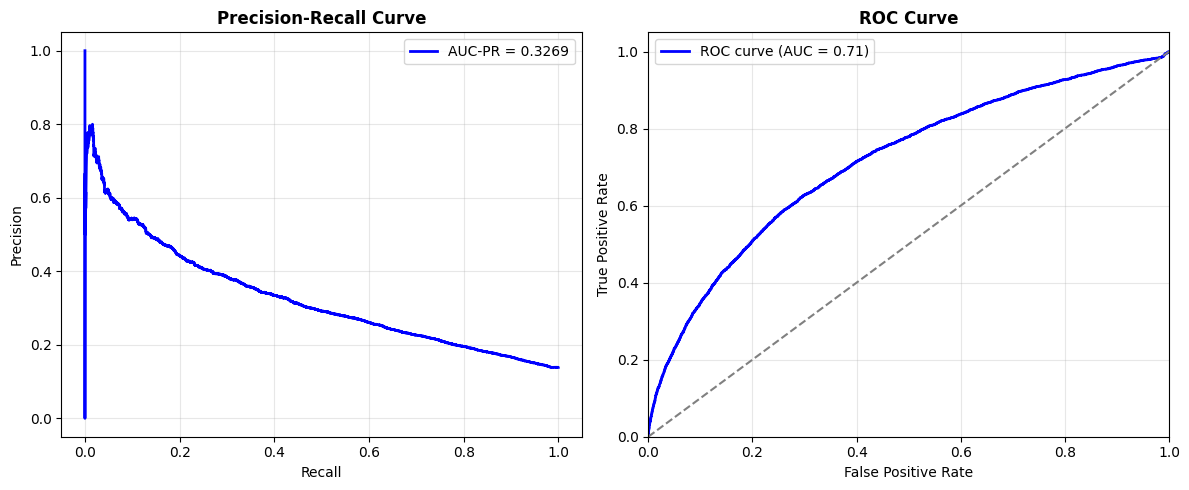

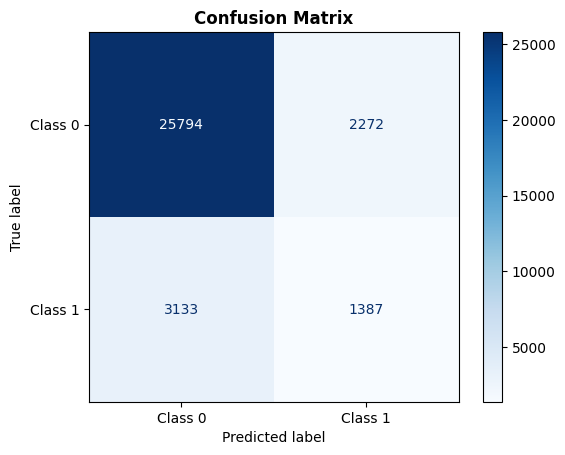

In [166]:
plot_PR_ROC_AUC(model_2_os, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_2_os, class_names= class_names)

In [167]:
model_3_os  = keras.models.Sequential([
  keras.layers.Flatten(input_shape=(1,train_set_smote.shape[1])),
  keras.layers.Dense(128, activation='relu'),
  keras.layers.Dropout(0.1),
  keras.layers.Dense(256, activation='relu'),
  keras.layers.Dropout(0.1),
  keras.layers.Dense(512, activation='relu'),
  keras.layers.Dropout(0.1),
  keras.layers.Dense(256, activation='relu'),
  keras.layers.Dropout(0.1),
  keras.layers.Dense(128, activation='relu'),
  keras.layers.Dense(1, activation='sigmoid')
])

/Users/lorisgiunta/.pyenv/versions/3.12.4/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [168]:
history_3_os, model_3_os = fit_NN(train_set_smote, train_label_smote, 0.001, 4096, 500, model_3_os, es_p=None, weights=False)

Epoch 1/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7759 - loss: 0.4901 - val_accuracy: 0.3989 - val_loss: 1.0282
Epoch 2/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8039 - loss: 0.4292 - val_accuracy: 0.4218 - val_loss: 0.9897
Epoch 3/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8071 - loss: 0.4228 - val_accuracy: 0.4506 - val_loss: 0.9081
Epoch 4/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8114 - loss: 0.4158 - val_accuracy: 0.4373 - val_loss: 0.9570
Epoch 5/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8125 - loss: 0.4138 - val_accuracy: 0.4682 - val_loss: 0.8745
Epoch 6/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8131 - loss: 0.4123 - val_accuracy: 0.4950 - val_loss: 0.8540
Epoch 7/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8149 - loss: 0.4088 - val_accuracy: 0.5085 - val_loss: 0.8332
Epoch 8/500
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8174 - loss: 0.4048 - 

In [169]:
model_3_os.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 994,181 (3.79 MB)

 Trainable params: 331,393 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 662,788 (2.53 MB)

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, loss, 'b', label='Training Loss', c='r')
/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_49617/3031977742.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs, val_loss, 'b', label='Validation Loss', c='b')


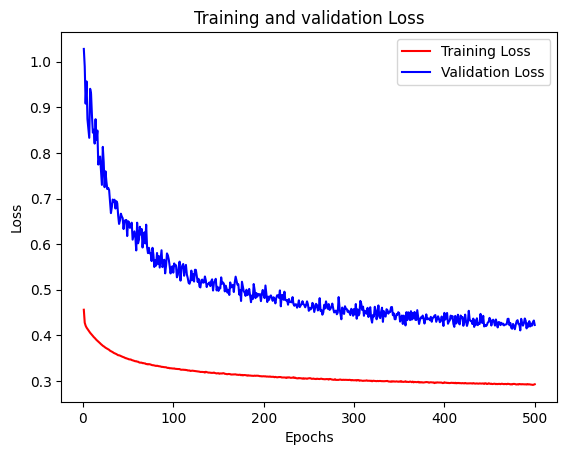

In [170]:
loss_plot(history_3_os)

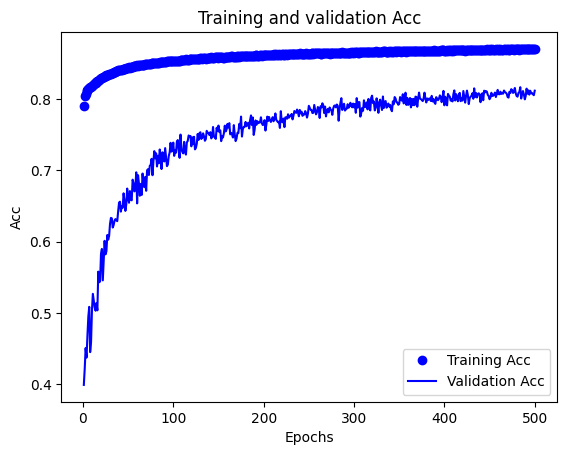

In [171]:
acc_plot(history_3_os)

In [172]:
y_pred_3_os = (model_3_os.predict(x_test) > 0.5).astype("int32").ravel()
print(y_pred_3_os)

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 1s 484us/step
[1 0 1 ... 0 0 0]


In [173]:
models.append(model_3_os)
predictions.append(y_pred_3_os)

In [174]:
print_report(train_label=None, train_predictions=None, validation_label=test_label, valid_predictions=y_pred_3_os)

TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.90      0.92      0.91     28066
       top20       0.41      0.34      0.37      4520

    accuracy                           0.84     32586
   macro avg       0.65      0.63      0.64     32586
weighted avg       0.83      0.84      0.83     32586



1019/1019 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step
AUC-PR of the classifier: 0.3465
AUC-ROC of the classifier: 0.7328


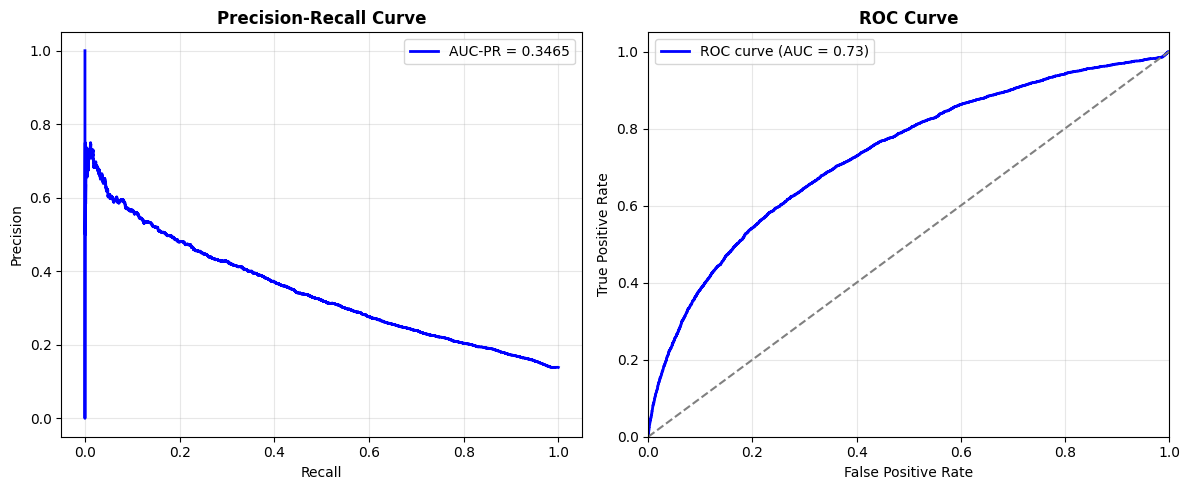

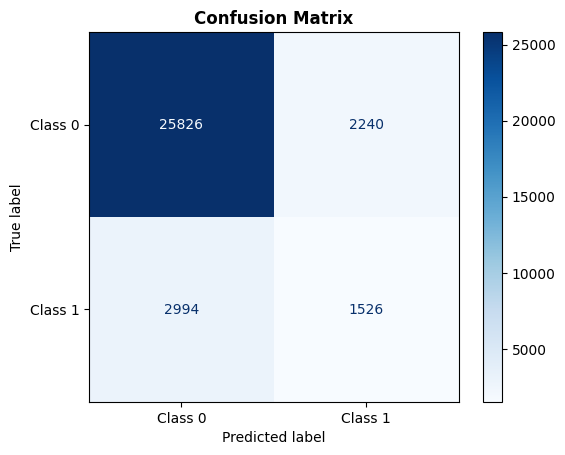

In [175]:
plot_PR_ROC_AUC(model_3_os, x_test, test_label)
plot_confusion_matrix_NN(prior_labels=test_label, predicted_labels= y_pred_3_os, class_names= class_names)

In [201]:
from sklearn.metrics import f1_score
def compare_f1_score(models:list, predictions:list, true_labels):
    macro_f1_scores = []
   
    for y_pred in predictions:
        score = f1_score(true_labels, y_pred, average='macro')
        macro_f1_scores.append(score)
        

    model_names = [model.name if hasattr(model, 'name') else f"Model {i+1}" for i, model in enumerate(models)]

    results = pd.DataFrame({'Model': model_names, 'Macro F1-Score': macro_f1_scores, 'Model Object': models})

   
    results = results.sort_values(by='Macro F1-Score', ascending=False)
    display(results[['Model', 'Macro F1-Score']])
   
    best_model = results.iloc[0]['Model Object']  
    return best_model
   

In [203]:
best_NN = compare_f1_score(models, predictions, test_label)

,Model,Macro F1-Score
9,sequential_9,0.650685
6,sequential_6,0.648038
5,sequential_5,0.645491
7,sequential_7,0.644551
12,sequential_12,0.638162
1,sequential_1,0.636944
2,sequential_2,0.636861
10,sequential_10,0.635544
4,sequential_4,0.631161
8,sequential_8,0.627336


In [204]:
best_NN.name

'sequential_9'